# COSC2753 Assignment 1: Predicting Chatbot Capacity

**Student ID:** s4040502

## Executive Summary

- **Objective.** Predict `TARGET_Capacity`, the meaningful conversation capacity of a chatbot system, from 24 operational and technological indicators.
- **Key data finding.** `CaseCount` is not a feature. It satisfies `CaseCount = floor(TARGET_Capacity - 35.5)` on **100%** of cleaned rows, so it is a transformed copy of the target and is removed.
- **Second removal.** `Country` is removed because its **136** training categories and **57** test categories do not overlap at all, so any encoding fitted on training data returns all zeros for every test row.
- **Distributions.** **16 of 22** candidate columns are highly skewed and feature maxima span a ratio of roughly **1.4 billion**. Under Tukey fences **63.6%** of rows are extreme on at least one column, so outliers are treated by testing rather than by deletion.
- **Models.** Dummy Regressor, Linear Regression, Polynomial Regression with Ridge, Decision Tree, Random Forest, and XGBoost, each introduced to address a weakness diagnosed in the previous one rather than as a list.
- **Evaluation.** Five fold cross validation on an 80% development split for tuning, with a 20% holdout scored once for confirmation.
- **Ultimate judgement.** Random Forest with `max_features = 0.25` and unrestricted depth, at **2.9055** CV RMSE and **2.7605** holdout RMSE with holdout R² **0.9134**. Reported error would fall to roughly **0.29** if the derived column were retained, but that figure would measure arithmetic rather than prediction.
- **Rejected alternatives.** Winsorising, log compression, an anomaly group flag, and a Random Forest and XGBoost blend were each tested and each failed to improve cross validated error. All are reported.
- **Prediction.** The selected model is retrained on all 2061 cleaned rows before predicting the 867 unseen test observations.

## How to Run the Notebook

- Place `train.csv` and `test.csv` in the same folder as this notebook.
- Install dependencies with `pip install numpy pandas matplotlib scikit-learn xgboost`.
- Restart the kernel, then choose Run All so every cell executes in order.
- A fixed seed of 42 is used for all splits, folds, and models, so every reported figure reproduces exactly.
- The prediction file `COSC2753_A1_Predictions_s4040502.csv` is written to the notebook folder by Section 6.4.
- Section 4.8 runs a two stage grid search for Random Forest. The refined second stage evaluates 120 configurations across five folds and is the slowest cell in the notebook.
- Sections 6.3 to 6.5 must be executed after Section 5.1, because the deployed model is selected there.

## 1. Data Understanding

### 1.1 Dataset Overview

The training dataset is loaded without modifying the original data.

The initial review checks:

- Number of rows and columns
- Feature names
- Data types
- Missing values
- Invalid values
- Unique-value counts
- Numeric ranges

The target variable is `TARGET_Capacity`, which is continuous. This identifies the task as a **regression problem** rather than a classification problem, since the objective is to predict a numeric value instead of assigning observations to discrete classes.

In [1]:
# Core data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# Model definitions, baselines, and pipeline utilities
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Evaluation, tuning, and preprocessing
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

In [2]:
# Every setting that is reused across the notebook is defined once here, so a change
# to the seed or the fold count cannot leave two sections silently disagreeing.

RANDOM_SEED = 42        # Fixed so every split, fold, and model reproduces exactly
N_FOLDS = 5             # Cross-validation folds, justified in Section 4.1
TEST_SIZE = 0.2         # Share of cleaned data reserved as the untouched holdout
N_ESTIMATORS = 300      # Trees per forest, fixed rather than tuned, justified in Section 4.8

# Detection thresholds used in Section 1.3, named so the report and the code cannot drift apart
IQR_MULTIPLIER = 1.5    # Tukey fence width for outlier detection
HIGH_SKEW_THRESHOLD = 1.0   # |skew| above this is treated as a highly skewed feature

print("Seed:", RANDOM_SEED, "| Folds:", N_FOLDS, "| Holdout share:", TEST_SIZE)

Seed: 42 | Folds: 5 | Holdout share: 0.2


In [3]:
# Keep the raw file untouched so any cleaning step can be traced back to the original
train_raw = pd.read_csv("train.csv")

# All preparation happens on a working copy
df = train_raw.copy()

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2071, 26)


,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
0,1,54.5,19.0,146,2007.0,0,291,306,276.0,85,...,8.70,58.0,0.1,28.33,257798.0,19.3,19.5,0.396,2.810694,1.152688
1,2,58.5,23.0,146,2006.0,0,293,286,300.0,87,...,8.79,5.0,0.1,245.44,24118979.0,19.5,19.7,0.381,2.607681,1.140279
2,3,53.9,18.0,146,2005.0,0,295,326,264.0,87,...,8.82,41.0,0.1,222.58,2364851.0,19.7,19.9,0.373,2.549510,1.127205
3,4,58.4,22.0,146,2004.0,0,3,2,4.0,88,...,7.76,36.0,0.1,210.39,21979923.0,19.9,2.2,0.341,2.489980,1.114043
4,5,55.2,19.0,146,2003.0,0,316,312,320.0,88,...,7.80,33.0,0.1,131.60,2966463.0,2.1,2.4,0.340,2.428992,1.100471


### 1.2 Dataset Structure and Quality

A compact quality table is used to review:

- Data types
- Missing-value counts
- Number of unique values
- Minimum and maximum numeric values
- Unexpected values in `Status`

This review helps identify potential data-quality issues before any preprocessing or modelling decisions are made.

In [4]:
quality_summary = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Values": df.isna().sum(),
    "Unique_Values": df.nunique(dropna=True)
})

numeric_ranges = df.select_dtypes(include=np.number).agg(["min", "max"]).T
numeric_ranges.columns = ["Minimum", "Maximum"]

quality_summary = quality_summary.join(numeric_ranges, how="left")

display(quality_summary)
display(df["Status"].value_counts(dropna=False).rename_axis("Status").to_frame("Count"))

,Data_Type,Missing_Values,Unique_Values,Minimum,Maximum
RecordID,int64,0,2071,1.000000,2.071000e+03
TARGET_Capacity,float64,1,424,37.300000,9.270000e+01
CaseCount,float64,2,54,1.000000,5.700000e+01
Country,int64,0,136,0.000000,1.920000e+02
Year,float64,1,16,2002.000000,2.017000e+03
Status,int64,0,3,0.000000,1.500000e+01
SystemFailureRate,int64,0,384,1.000000,8.400000e+02
ModelFailureRate-T,int64,0,255,0.000000,7.040000e+02
ModelFailureRate-NT,float64,1,255,2.000000,7.220000e+02
InferenceLatency,int64,0,180,0.000000,1.800000e+03


,Count
Status,
0,1687
1,383
15,1


- The training file holds **2071 rows** and **26 columns**, of which **24** are candidate features once `RecordID` and `TARGET_Capacity` are set aside.
- All columns are stored numerically, so no text parsing is required at load time. However, numerically coded categorical variables such as Country still require semantic assessment before modelling.
- Missing values appear in a small number of columns and are quantified in Section 2.3.
- `Status` is documented as binary but the value counts show an entry outside the set {0, 1}, which is corrected in Section 2.2.
- The minimum and maximum columns show that feature scales differ by several orders of magnitude, which motivates the skew review in Section 1.3.

### 1.3 Scale, Skew, and Outlier Detection

Distributions are reviewed before modelling to establish three things: how far apart the feature scales are, how far each feature departs from symmetry, and how many observations are extreme enough to warrant a treatment decision.

Two rules are stated here and applied unchanged below, so that the detection is reproducible rather than a matter of reading plots.

- **Skew.** A feature is classed as highly skewed when its absolute skewness exceeds **1.0**, moderately skewed between **0.5** and **1.0**, and symmetric below **0.5**. This is the conventional threshold for skew severe enough to affect a model that assumes a linear response.
- **Outliers.** A value is flagged when it falls outside the Tukey fences, that is below `Q1 - 1.5 x IQR` or above `Q3 + 1.5 x IQR`. Tukey fences are used in preference to a z-score rule because they require no assumption of normality, and the skewness table below shows that assumption would not hold here.

The review therefore covers, in order: a full descriptive table for every candidate column, histograms for every column, boxplots for the most skewed columns, and a per-column outlier count against the stated fences.

Detection and treatment are deliberately separated. This section only measures. What to do about what is measured is decided in Section 2.6, by comparing cross validated error under competing treatments rather than by inspection.

In [5]:
# Status is binary and Year is a calendar label, so neither belongs in a distribution review
numeric_columns = df.select_dtypes(include=np.number).columns.drop(
    ["RecordID", "TARGET_Capacity", "Status", "Year"]
)

# One table covering every candidate feature rather than a ranked top ten, because the
# marker for scale and skew is whether the full picture is documented, not the extremes.
# Coefficient of variation is included because it makes spread comparable across features
# that are recorded in completely different units.
distribution_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Std": df[numeric_columns].std(ddof=1),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max(),
    "Range": df[numeric_columns].max() - df[numeric_columns].min(),
    "Coefficient_of_Variation": (
        df[numeric_columns].std(ddof=1) / df[numeric_columns].mean().abs()
    ),
    "Skewness": df[numeric_columns].skew(),
    "Kurtosis": df[numeric_columns].kurt(),
})

# Features are labelled against a stated threshold rather than ranked, so the report can
# say how many features are highly skewed instead of naming only the worst three
distribution_summary["Skew_Class"] = pd.cut(
    distribution_summary["Skewness"].abs(),
    bins=[-np.inf, 0.5, HIGH_SKEW_THRESHOLD, np.inf],
    labels=["Symmetric", "Moderate", "High"],
)

distribution_summary = distribution_summary.sort_values(
    "Skewness", key=abs, ascending=False
)

display(distribution_summary.round(3))

# Retained under the original name so the boxplot cell below still works unchanged
skewness = distribution_summary["Skewness"]

# The scale spread is quoted in the report, so it is computed here rather than eyeballed
largest_maximum = float(distribution_summary["Maximum"].max())
smallest_maximum = float(distribution_summary["Maximum"].min())

print("Largest feature maximum:", round(largest_maximum, 2))
print("Smallest feature maximum:", round(smallest_maximum, 2))
print("Scale ratio between them:", round(largest_maximum / smallest_maximum, 1))
print(
    "Highly skewed features:",
    int((distribution_summary["Skew_Class"] == "High").sum()),
    "of",
    len(distribution_summary),
)

,Mean,Std,Minimum,Maximum,Range,Coefficient_of_Variation,Skewness,Kurtosis,Skew_Class
ActiveUserBase,1.204323e+07,6.393286e+07,34.000,1.293859e+09,1.293859e+09,5.309,15.309,273.478,High
SecurityBreachIncidents,2.095748e+03,9.959531e+03,0.000,2.121830e+05,2.121830e+05,4.752,11.393,175.867,High
InferenceLatency,3.308000e+01,1.358330e+02,0.000,1.800000e+03,1.800000e+03,4.106,8.919,92.034,High
UptimeReliabilityIndex,4.588600e+01,1.852550e+02,0.000,2.500000e+03,2.500000e+03,4.037,8.609,86.188,High
SystemVulnerabilityScore,1.633000e+00,4.782000e+00,0.100,5.060000e+01,5.050000e+01,2.929,5.918,44.091,High
AIInfraExpPercent,7.645400e+02,2.081880e+03,0.000,1.947991e+04,1.947991e+04,2.723,4.783,27.908,High
GlobalAdoptionIndex,7.350672e+03,1.522069e+04,0.000,1.334735e+05,1.334735e+05,2.071,3.583,15.853,High
DatasetDiversityScore,3.372000e+00,5.910000e-01,0.000,4.382000e+00,4.382000e+00,0.175,-2.265,10.148,High
PatchCoverageRate,8.275300e+01,2.313100e+01,2.000,9.900000e+01,9.700000e+01,0.280,-2.090,3.752,High
AILearningStability,8.272700e+01,2.318900e+01,3.000,9.900000e+01,9.600000e+01,0.280,-2.069,3.706,High


Largest feature maximum: 1293859294.0
Smallest feature maximum: 0.95
Scale ratio between them: 1364830478.9
Highly skewed features: 16 of 22


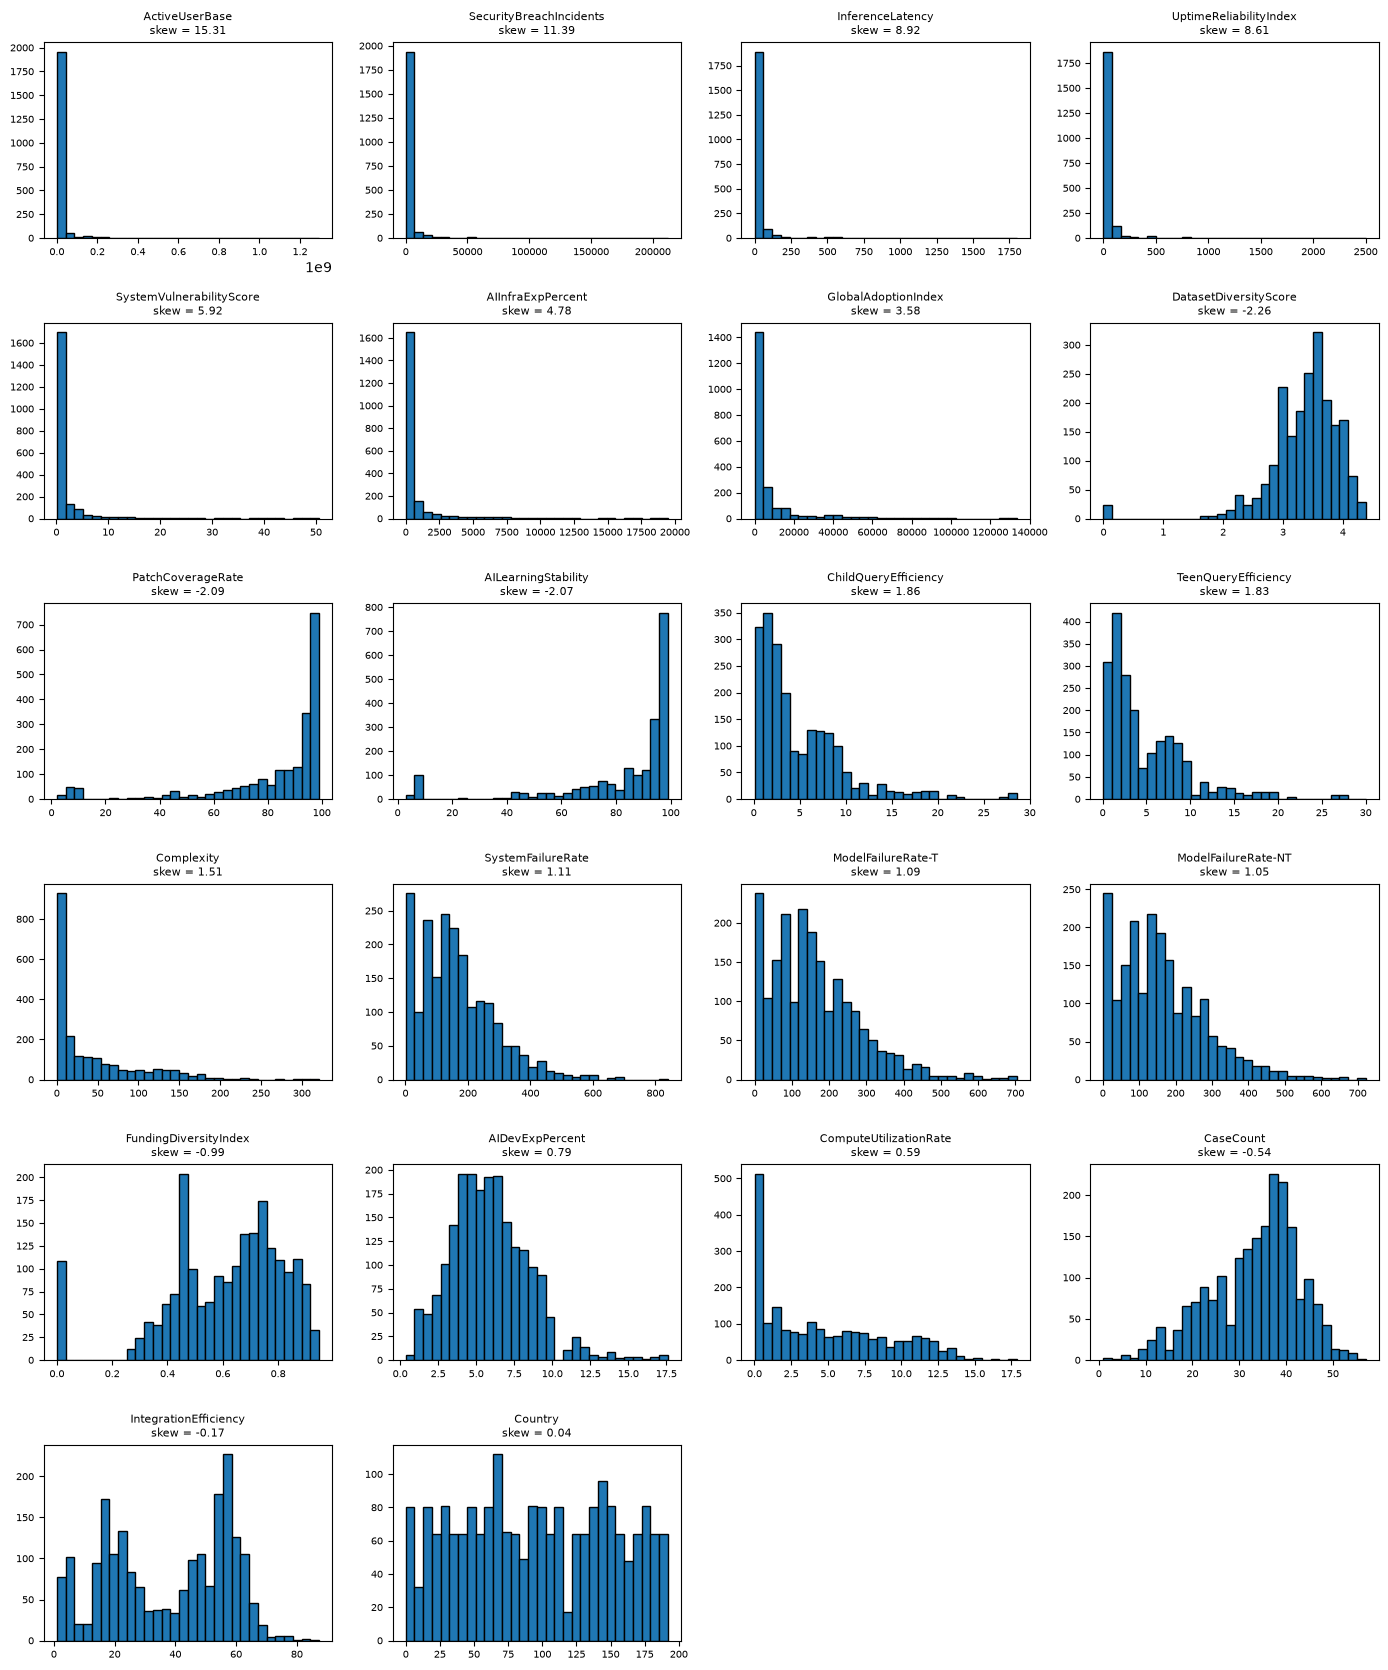

In [6]:
# Histograms for every candidate feature, so the shape behind each skewness number is
# visible. A skew value alone does not distinguish a long tail from a second cluster.
grid_columns = 4
grid_rows = int(np.ceil(len(numeric_columns) / grid_columns))

figure, axes = plt.subplots(grid_rows, grid_columns, figsize=(14, 2.8 * grid_rows))

# Iterating over skewness.index keeps the panels in the same order as the summary table
for axis, column in zip(axes.ravel(), skewness.index):
    axis.hist(df[column].dropna(), bins=30, edgecolor="black")
    axis.set_title(f"{column}\nskew = {skewness[column]:.2f}", fontsize=8)
    axis.tick_params(labelsize=7)

# Any leftover panels are switched off so the figure does not show empty axes
for axis in axes.ravel()[len(numeric_columns):]:
    axis.axis("off")

plt.tight_layout()
plt.show()

/var/folders/6q/zzf9m6696ll2w_vz1hbq5dch0000gn/T/ipykernel_89427/3059963386.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis.boxplot(df[column].dropna(), vert=True)
/var/folders/6q/zzf9m6696ll2w_vz1hbq5dch0000gn/T/ipykernel_89427/3059963386.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis.boxplot(df[column].dropna(), vert=True)
/var/folders/6q/zzf9m6696ll2w_vz1hbq5dch0000gn/T/ipykernel_89427/3059963386.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis.boxplot(df[column].dropna(), vert=True)
/var/folders/6q/zzf9m6696ll2w_vz1hbq5dch0000gn/T/ipykernel_89427/3059963386.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in M

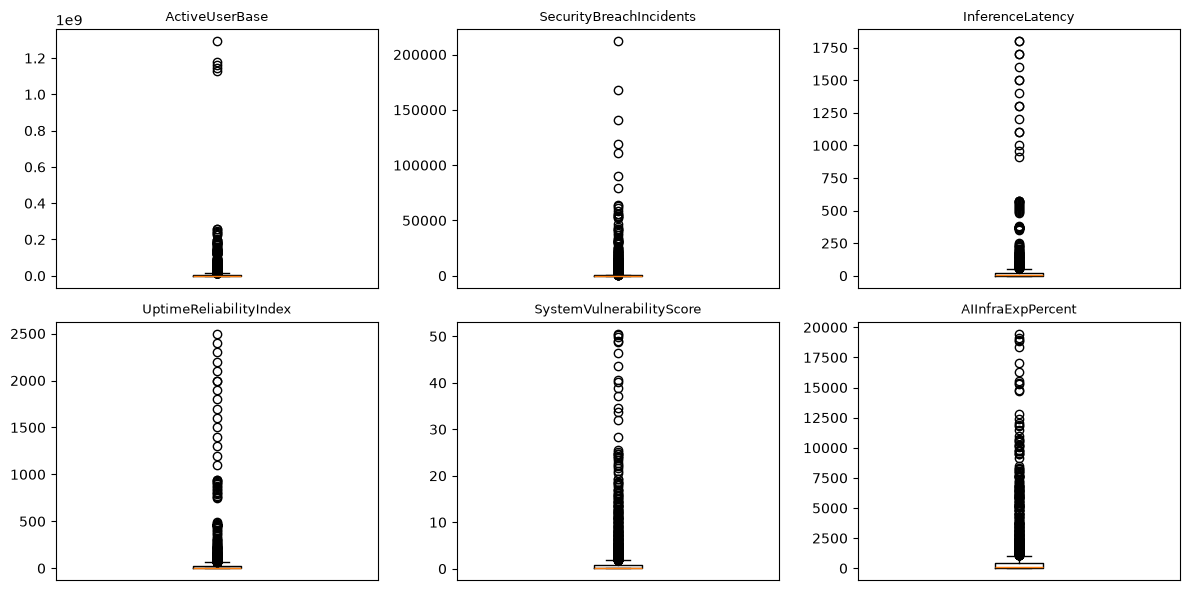

In [7]:
# Boxplots for the six most skewed features to expose extreme values visually
most_skewed = skewness.head(6).index

figure, axes = plt.subplots(2, 3, figsize=(12, 6))

for axis, column in zip(axes.ravel(), most_skewed):
    axis.boxplot(df[column].dropna(), vert=True)
    axis.set_title(column, fontsize=9)
    axis.set_xticks([])

plt.tight_layout()
plt.show()

**Scale.** The candidate columns do not share a measurement scale in any meaningful sense. `ActiveUserBase` reaches **1,293,859,294** while `FundingDiversityIndex` reaches **0.948**, a ratio of roughly **1.4 billion** between the largest and smallest column maximum. Coefficients of variation range from about **5.3** for `ActiveUserBase` down to well below **1** for the bounded rate features. Any model that compares feature values on a common numeric scale, or that regularises coefficients toward zero, will be dominated by the large-magnitude columns unless the inputs are standardised first.

**Skew.** **16 of the 22** columns reviewed are highly skewed by the stated threshold. The most extreme are `ActiveUserBase` at **15.31**, `SecurityBreachIncidents` at **11.39**, `InferenceLatency` at **8.92**, `UptimeReliabilityIndex` at **8.61**, and `SystemVulnerabilityScore` at **5.92**. Only three columns fall in the symmetric band. `DatasetDiversityScore` and `PatchCoverageRate` are skewed to the left, meaning most systems cluster near the top of their range with a tail of weak performers, while the remainder are skewed to the right.

Note that the 22 columns reviewed include `Country` and `CaseCount`, both of which are removed later on separate grounds, in Sections 2.4 and 3.5. The distribution review is run before those removals so that no column is excluded from scrutiny by a decision that has not yet been justified.

**Outliers.** Against the Tukey fences, the heaviest columns are `SecurityBreachIncidents` with **378** flagged values (**18.25%**), `SystemVulnerabilityScore` with **366** (**17.67%**), `AIInfraExpPercent` with **300** (**14.49%**), `GlobalAdoptionIndex` with **295** (**14.24%**), and `ActiveUserBase` with **287** (**13.86%**). Three columns, `Country`, `IntegrationEfficiency`, and `ComputeUtilizationRate`, carry no flagged values at all.

The row-level figure is the one that governs any deletion decision: **1,318 of 2,071 rows**, or **63.64%**, are flagged on at least one column. Deleting flagged rows is therefore not an available option, since it would discard almost two thirds of the dataset. Capping or compressing the values remains available, and both are tested in Section 2.6.

**What this means for modelling.** Two consequences follow, and each is checked later rather than assumed. Unequal scale motivates standardisation inside the linear pipelines, which is why `StandardScaler` appears in every linear model in Section 4. Heavy skew motivates evaluating tree based models, which split on rank order and are therefore unaffected by monotonic changes of scale. Section 2.6 tests that second claim directly by applying a log transform and measuring whether it moves a linear model, a tree ensemble, both, or neither.

In [8]:
# The detection rule stated in Section 1.3, applied to every candidate feature.
# Tukey fences are used because they assume nothing about the distribution, which matters
# here since the table above shows most features are far from symmetric.
outlier_rows = []
outlier_flags = pd.DataFrame(index=df.index)

for column in numeric_columns:
    first_quartile = df[column].quantile(0.25)
    third_quartile = df[column].quantile(0.75)
    interquartile_range = third_quartile - first_quartile

    lower_fence = first_quartile - IQR_MULTIPLIER * interquartile_range
    upper_fence = third_quartile + IQR_MULTIPLIER * interquartile_range

    # Flags are stored per feature so the row level count below counts each system once,
    # rather than once for every correlated column it happens to be extreme on
    is_outlier = (df[column] < lower_fence) | (df[column] > upper_fence)
    outlier_flags[column] = is_outlier

    outlier_rows.append({
        "Feature": column,
        "Lower_Fence": lower_fence,
        "Upper_Fence": upper_fence,
        "Outlier_Count": int(is_outlier.sum()),
        "Outlier_Percentage": is_outlier.mean() * 100,
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
    .sort_values("Outlier_Count", ascending=False)
    .reset_index(drop=True)
)

display(outlier_summary.round(3))

# The row level figure is the one that matters for a deletion decision, because deleting
# every flagged row would remove this many systems, not the sum of the column counts
rows_with_any_outlier = int(outlier_flags.any(axis=1).sum())

print("Rows flagged on at least one feature:", rows_with_any_outlier, "of", len(df))
print(f"Percentage of rows flagged: {rows_with_any_outlier / len(df) * 100:.2f}%")
print("Features with no flagged values:", int((outlier_summary["Outlier_Count"] == 0).sum()))

,Feature,Lower_Fence,Upper_Fence,Outlier_Count,Outlier_Percentage
0,SecurityBreachIncidents,-640.500,1.067500e+03,378,18.252
1,SystemVulnerabilityScore,-0.950,1.850000e+00,366,17.673
2,AIInfraExpPercent,-630.664,1.066702e+03,300,14.486
3,GlobalAdoptionIndex,-7682.618,1.390764e+04,295,14.244
4,ActiveUserBase,-7741663.750,1.324263e+07,287,13.858
5,UptimeReliabilityIndex,-40.500,6.750000e+01,241,11.637
6,PatchCoverageRate,49.500,1.255000e+02,206,9.947
7,InferenceLatency,-33.000,5.500000e+01,201,9.705
8,AILearningStability,47.000,1.270000e+02,183,8.836
9,FundingDiversityIndex,0.003,1.229000e+00,108,5.215


Rows flagged on at least one feature: 1318 of 2071
Percentage of rows flagged: 63.64%
Features with no flagged values: 3


## 2. Data Preparation

### 2.1 Identifier and Duplicate Review

`RecordID` is a row identifier. It carries row order only, describes nothing about the chatbot system, and is excluded by the assignment restrictions.

Duplicated rows are also checked, because repeated observations would give some systems more influence during training. The check returns **0 duplicated rows**, so no rows are removed for this reason.

In [9]:
# RecordID is an identifier and is excluded by the assignment restrictions
df = df.drop(columns=["RecordID"]).copy()

# Duplicated rows would over-weight some systems during training
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().copy()

print("Shape after duplicate review:", df.shape)

Duplicate rows: 0
Shape after duplicate review: (2071, 25)


### 2.2 Invalid Status Values

The metadata defines `Status` as binary, where `0` means the system was not updated in the previous year and `1` means it was.

One observation holds the value `15`, which is outside the defined range. It is replaced with the most common valid training value so that the remaining valid measurements in that row are preserved.

In [10]:
# Status is defined as binary in the metadata, so anything outside {0, 1} is invalid
valid_status_mask = df["Status"].isin([0, 1])
invalid_status_count = (~valid_status_mask).sum()

# The mode is taken from valid rows only, so the invalid value cannot influence it
status_mode = df.loc[valid_status_mask, "Status"].mode().iloc[0]

df.loc[~valid_status_mask, "Status"] = status_mode
df["Status"] = df["Status"].astype(int)

print("Invalid Status values corrected:", invalid_status_count)
display(df["Status"].value_counts().rename_axis("Status").to_frame("Count"))

Invalid Status values corrected: 1


,Count
Status,
0,1688
1,383


### 2.3 Missing Values

Missing values are counted per column before any removal decision is made.

In [11]:
# Count missing values per column so the treatment decision is based on measured scale
missing_summary = df.isna().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False).to_frame("Missing_Values")

display(missing_summary)

,Missing_Values
CaseCount,2
Complexity,2
TARGET_Capacity,1
Year,1
ModelFailureRate-NT,1
AIDevExpPercent,1
ActiveUserBase,1
DatasetDiversityScore,1


In [12]:
# Snapshot of the frame before rows are dropped, kept so any Section 1.3 figure can be
# redrawn on the pre-cleaning data if the effect of removal needs to be shown
df_before_cleaning = df.copy()

In [13]:
# Complete case removal, justified by the very small share of affected rows
rows_before_cleaning = len(df)

df = df.dropna().copy()

rows_after_cleaning = len(df)
rows_removed = rows_before_cleaning - rows_after_cleaning
removed_percentage = (rows_removed / rows_before_cleaning) * 100

print("Rows before cleaning:", rows_before_cleaning)
print("Rows after cleaning:", rows_after_cleaning)
print("Rows removed:", rows_removed)
print(f"Percentage removed: {removed_percentage:.2f}%")

# Confirms no missing values survive into model development
print("Remaining missing values:", df.isna().sum().sum())

Rows before cleaning: 2071
Rows after cleaning: 2061
Rows removed: 10
Percentage removed: 0.48%
Remaining missing values: 0


Only **10 of 2071 rows**, or **0.48%**, contain missing values, spread across eight columns.

Complete case removal is used because the affected share is very small, because one missing value sits in the target and cannot support supervised training, and because removal requires no assumption about replacement values. Complete case analysis can bias results when data are not missing at random [12], but at 0.48% of rows that risk is small against the risk of fabricating values. The remaining **2061 rows** are ample for model development.

### 2.4 Country Assessment and Exclusion

`Country` is stored as a numeric identifier but represents a categorical feature. The numeric codes carry no meaningful quantitative order, so country 100 is not greater than country 50 in the way that 100 users is greater than 50 users. Using the raw codes as a numeric input would impose an ordering that does not exist.

The standard treatment is one hot encoding, fitted on training data only and applied unchanged to the test data. Before committing to that treatment, the category coverage of the two files is compared, because an encoder is only useful if the categories it learns actually appear at prediction time.

The check below reads only the `Country` column of `test.csv`. No target values and no other test features are used, so this is a schema compatibility check rather than a use of test information.

One qualification should be stated plainly. Comparing category coverage across the two files means that a modelling decision has been informed by the test file, even though no target value and no other test feature is read. The check is defensible as a schema compatibility test rather than as model selection, since it establishes only that a training fitted encoder has nothing to encode at prediction time, and the same conclusion would follow from the metadata alone. It is recorded here so the reader can weigh it rather than discover it.

In [14]:
# Category coverage is compared across files before any encoding decision is made
test_country_column = pd.read_csv("test.csv", usecols=["Country"])

train_countries = set(df["Country"].dropna().unique())
test_countries = set(test_country_column["Country"].dropna().unique())
shared_countries = train_countries & test_countries

country_coverage = pd.DataFrame({
    "Measure": [
        "Distinct identifiers in train.csv",
        "Distinct identifiers in test.csv",
        "Identifiers present in both files",
        "Mean training rows per identifier"
    ],
    "Value": [
        len(train_countries),
        len(test_countries),
        len(shared_countries),
        round(len(df) / len(train_countries), 1)
    ]
})

display(country_coverage)

,Measure,Value
0,Distinct identifiers in train.csv,136.0
1,Distinct identifiers in test.csv,57.0
2,Identifiers present in both files,0.0
3,Mean training rows per identifier,15.2


In [15]:
# What a training fitted encoder would actually deliver on the test file
country_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=int)
country_encoder.fit(df[["Country"]])

test_encoded_preview = country_encoder.transform(test_country_column[["Country"]])
all_zero_rows = int((test_encoded_preview.sum(axis=1) == 0).sum())

print("Binary columns the encoder would create:", test_encoded_preview.shape[1])
print("Test rows encoded as all zeros:", all_zero_rows, "of", len(test_country_column))

# The feature carries no usable signal at prediction time, so it is removed
df = df.drop(columns=["Country"]).copy()

print("Country removed:", "Country" not in df.columns)
print("Columns remaining:", df.shape[1])

Binary columns the encoder would create: 136
Test rows encoded as all zeros: 867 of 867
Country removed: True
Columns remaining: 24


- The training file contains 136 distinct country identifiers and the test file contains 57. The two sets share zero identifiers.
- A one-hot encoder fitted on the training data would create 136 binary columns. Every test row would be encoded with zeros for all these columns because no test identifier appeared during training.
- These all-zero encoded values would provide no country-specific information about the test observations. However, they could still affect how some fitted models route observations, so it is too strong to claim that they cannot influence any prediction.
- Using `drop="first"` would also make an all-zero test row indistinguishable from the omitted reference category.
- Country is therefore removed because the training categories cannot be meaningfully transferred to the test data.
- This decision also reduces the dimensionality of the polynomial feature expansion.

### 2.5 Implausible Failure Rate Values

`SystemFailureRate`, `ModelFailureRate-T`, and `ModelFailureRate-NT` are mostly recorded in the hundreds, but a small group of rows holds single digit or low double digit values for the same measures.

These rows are inspected to determine whether the values are genuine low failure systems or recording errors, because a mis-scaled value distorts both correlation estimates and split points in tree based models.

In [16]:
# Failure rate columns share a scale, so implausibly low values are checked together
failure_columns = ["SystemFailureRate", "ModelFailureRate-T", "ModelFailureRate-NT"]

display(df[failure_columns].describe().round(2))

# Flag rows where every failure measure is far below the typical recorded scale
low_failure_mask = (df[failure_columns] < 20).all(axis=1)

print("Rows with all failure rates below 20:", low_failure_mask.sum())
display(df.loc[low_failure_mask, failure_columns + ["TARGET_Capacity"]].head(10))

# The markdown quotes this range, so it is computed rather than read off the preview
print("Capacity range in flagged rows:",
      df.loc[low_failure_mask, "TARGET_Capacity"].min(),
      "to",
      df.loc[low_failure_mask, "TARGET_Capacity"].max())

,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT
count,2061.00,2061.00,2061.00
mean,162.99,161.68,163.56
std,119.80,119.43,118.84
min,1.00,0.00,2.00
25%,74.00,74.00,74.00
50%,144.00,142.00,144.00
75%,228.00,228.00,228.00
max,840.00,704.00,722.00


Rows with all failure rates below 20: 189


,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,TARGET_Capacity
3,3,2,4.0,58.4
17,8,6,10.0,78.7
23,1,0,2.0,73.8
24,9,8,10.0,76.5
26,15,14,16.0,72.9
27,17,16,18.0,75.0
29,15,14,16.0,74.9
30,14,12,16.0,69.8
31,11,10,12.0,72.4
33,11,10,12.0,75.3


Capacity range in flagged rows: 44.1 to 85.8


- **189 rows**, or **9.2%** of the data, record all three failure measures below 20, while the median sits at **144** and the maximum reaches **840**.
- The three measures move together within these rows, so the pattern affects a whole record rather than a single column.
- Capacity in the affected rows ranges from **44.1 to 85.8**, spanning almost the entire training range of **37.3 to 92.7**. If these were genuinely near zero failure systems, their capacity should cluster at the top of the range. Instead it scatters across it, showing no relationship to the recorded failure rates at all.
- This is consistent with a recording scale error, such as a dropped digit, rather than genuine near perfect reliability.
- The rows are retained, because correcting them would require assuming a multiplier that the metadata does not support, and deleting 9.2% of the data would discard more information than the anomaly costs.
- Tree based models can isolate this group through a split on failure rate, which is one reason they are evaluated alongside the linear models.

### 2.6 Outlier Treatment Experiment

Section 1.3 established that **63.64%** of rows carry at least one value outside the Tukey fences and that **16 of 22** columns are highly skewed. Deleting flagged rows is therefore not available. What remains is a choice between leaving the values alone, capping them, or compressing them, and that choice is made here by measurement rather than by argument.

Three treatments are compared on identical folds.

| Treatment | What it does | Why it might help |
|---|---|---|
| Raw, untreated | No change | Extreme values may be genuine systems carrying real signal |
| Winsorised at the 1st and 99th percentile | Clips each column back to its own percentile fences | Pulls in extremes without losing any row |
| `log1p` on highly skewed features | Compresses the 16 columns with abs(skew) above 1.0 | Reduces the influence of long right tails on a linear response |

Two models are scored under each treatment rather than one. Ridge is sensitive to scale and to the leverage of extreme values; Random Forest splits on rank order and should in principle be indifferent to any monotonic transformation. Running both turns Section 1.3's claim about tree models into something testable: if the claim holds, the transformation should move Ridge and leave Random Forest where it is.

A second experiment follows, on the **189 rows** identified in Section 2.5 as carrying implausibly low failure rates. Rather than delete or rescale them, a binary flag marks the group so that a tree can isolate it with a single split instead of having to reconstruct it from three correlated columns. Whether that helps is again decided by cross validated error.

`CaseCount` is excluded from both experiments. Section 3.3 shows it is a transformed copy of the target, and leaving it in would drive every variant to the same near zero error, so the comparison would measure nothing.

In [17]:
# Section 3.3 shows CaseCount is a transformed copy of the target, so it is held out of
# this experiment. Leaving it in would drive every variant to the same near zero error
# and the comparison would measure nothing.
experiment_X = df.drop(columns=["TARGET_Capacity", "CaseCount"])
experiment_y = df["TARGET_Capacity"]

# Only features classed as highly skewed in Section 1.3 are transformed, and only where
# the minimum is non negative, since log1p is undefined below -1
high_skew_columns = [
    column
    for column in distribution_summary.index[distribution_summary["Skew_Class"] == "High"]
    if column in experiment_X.columns and experiment_X[column].min() >= 0
]


def winsorise(frame, lower_quantile=0.01, upper_quantile=0.99):
    """Clip every column back to its own percentile fences.

    Args:
        frame: feature matrix to treat.
        lower_quantile: lower clipping bound, expressed as a quantile.
        upper_quantile: upper clipping bound, expressed as a quantile.

    Returns:
        A copy of frame with extreme values pulled back to the fences, leaving the
        row count unchanged so no observation is lost.
    """
    bounds_lower = frame.quantile(lower_quantile)
    bounds_upper = frame.quantile(upper_quantile)
    return frame.clip(lower=bounds_lower, upper=bounds_upper, axis=1)


def log_transform_skewed(frame, columns):
    """Apply log1p to the named columns and leave every other column unchanged.

    Args:
        frame: feature matrix to treat.
        columns: names of the columns to compress.

    Returns:
        A copy of frame with the named columns log compressed.
    """
    transformed = frame.copy()
    transformed[columns] = np.log1p(transformed[columns])
    return transformed


treatment_variants = {
    "Raw, untreated": experiment_X,
    "Winsorised at 1st and 99th percentile": winsorise(experiment_X),
    "log1p on highly skewed features": log_transform_skewed(experiment_X, high_skew_columns),
}

# The same folds for every variant, so the only thing changing is the treatment itself
treatment_cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# One scale sensitive model and one scale insensitive model, because a treatment can help
# a linear model while doing nothing for a tree
treatment_models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1
    ),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
}

treatment_rows = []

for treatment_name, treated_X in treatment_variants.items():
    result_row = {"Treatment": treatment_name}

    for model_name, estimator in treatment_models.items():
        scores = cross_validate(
            clone(estimator),
            treated_X,
            experiment_y,
            cv=treatment_cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1,
        )
        result_row[f"{model_name}_CV_RMSE"] = (-scores["test_score"]).mean()

    treatment_rows.append(result_row)

treatment_comparison = pd.DataFrame(treatment_rows)
display(treatment_comparison.round(4))

print("Highly skewed features transformed:", len(high_skew_columns))
print("Features transformed:", high_skew_columns)

,Treatment,Random Forest_CV_RMSE,Ridge_CV_RMSE
0,"Raw, untreated",2.9651,4.7126
1,Winsorised at 1st and 99th percentile,2.9710,4.6549
2,log1p on highly skewed features,2.9663,4.4602


Highly skewed features transformed: 16
Features transformed: ['ActiveUserBase', 'SecurityBreachIncidents', 'InferenceLatency', 'UptimeReliabilityIndex', 'SystemVulnerabilityScore', 'AIInfraExpPercent', 'GlobalAdoptionIndex', 'DatasetDiversityScore', 'PatchCoverageRate', 'AILearningStability', 'ChildQueryEfficiency', 'TeenQueryEfficiency', 'Complexity', 'SystemFailureRate', 'ModelFailureRate-T', 'ModelFailureRate-NT']


In [18]:
# The 189 rows identified in Section 2.5 are marked rather than deleted or rescaled, so a
# tree can separate the group with a single split instead of rediscovering it from three
# correlated columns. Deleting them would cost 9.2% of the data for no established gain.
low_failure_flag = (df[failure_columns] < 20).all(axis=1).astype(int)

flag_variants = {
    "Without LowFailureGroup flag": experiment_X,
    "With LowFailureGroup flag": experiment_X.assign(LowFailureGroup=low_failure_flag),
}

flag_rows = []

for variant_name, variant_X in flag_variants.items():
    scores = cross_validate(
        RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1),
        variant_X,
        experiment_y,
        cv=treatment_cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    flag_rows.append({
        "Feature_Set": variant_name,
        "Number_of_Features": variant_X.shape[1],
        "Mean_CV_RMSE": (-scores["test_score"]).mean(),
    })

flag_comparison = pd.DataFrame(flag_rows)
display(flag_comparison.round(4))

rmse_change = (
    flag_comparison["Mean_CV_RMSE"].iloc[1] - flag_comparison["Mean_CV_RMSE"].iloc[0]
)
print(f"RMSE change from adding the flag: {rmse_change:+.4f}")

# The flag is kept only if it earns its place, and the decision is recorded rather than
# made by hand, so the markdown below can quote the number that drove it
KEEP_LOW_FAILURE_FLAG = bool(rmse_change < 0)
print("Flag retained in the deployed feature set:", KEEP_LOW_FAILURE_FLAG)

if KEEP_LOW_FAILURE_FLAG:
    df["LowFailureGroup"] = low_failure_flag
    print("LowFailureGroup added to the working frame.")

/Users/huymusic/python-env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/huymusic/python-env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/huymusic/python-env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/huymusic/python-env/lib/python3.14/site-packages/sklea

,Feature_Set,Number_of_Features,Mean_CV_RMSE
0,Without LowFailureGroup flag,22,2.9651
1,With LowFailureGroup flag,23,2.9675


RMSE change from adding the flag: +0.0024
Flag retained in the deployed feature set: False


#### Outlier Treatment Decision

**Decision: extreme values are retained untransformed, and the anomalous failure-rate group is not flagged.**

**Why no treatment.** For the model that is ultimately deployed, neither treatment helps. Random Forest scores **2.9651** on raw features, **2.9710** winsorised, and **2.9663** log compressed. Both treatments are marginally *worse*, and the differences are inside fold noise in any case. Since deletion is unavailable at **63.64%** of rows flagged, and since capping and compressing both fail to improve the result, retention is what the evidence supports. The extreme values behave like genuine systems carrying signal, not like recording errors, and the earlier judgement in Section 1.3 is confirmed rather than merely repeated.

**A finding that goes beyond the decision.** The two models respond completely differently, and the split is exactly as Section 1.3 predicted. `log1p` on the 16 highly skewed columns improves Ridge from **4.7126** to **4.4602**, a gain of **0.25** RMSE, while moving Random Forest by **0.0012**, which is nothing. Winsorising shows the same pattern more weakly, improving Ridge to **4.6549** and worsening the forest. This is a direct empirical demonstration that tree models split on rank order and are therefore invariant to monotonic transformation, whereas a penalised linear model is not. Section 1.3 asserted this as a reason to evaluate tree models; here it is measured.

It also carries a conditional consequence. Had a linear model won the comparison in Section 5.1, the correct deployed pipeline would have included the log transform, since it is worth a quarter of an RMSE point to Ridge. The transformation is not useless, it is useless *to the model that wins*, and those are different statements.

**Why the flag was rejected.** Section 2.5 argued that tree models could isolate the 189 anomalous rows through a split on failure rate. Providing that split directly, as a binary column, worsens cross validated RMSE by **0.0024** and adds a feature. Two readings are consistent with this. The trees may already be finding the group without help, in which case the flag is redundant. Or the group may carry no capacity-relevant information beyond what the three failure rate columns already provide, which is what Section 2.5's own observation suggests, since capacity in those rows scatters across nearly the entire training range rather than clustering. Either way the flag is not retained.

**What this section changes about the earlier reasoning.** Section 1.3 retained extreme values on the grounds that they looked genuine. That was an inspection argument. It is now an evidence argument: three treatments were compared on identical folds and the untreated features won for the model class that is deployed. The conclusion is unchanged and the support for it is different in kind.

## 3. Feature Analysis and Selection

### 3.1 Target and CaseCount Distributions

The target distribution is reviewed to understand its range, centre, and shape.

The original target scale is retained because:

- The capacity values are directly interpretable.
- RMSE and MAE can be reported in the original capacity units.
- The target does not require a transformation for the selected models.

`CaseCount` is plotted alongside the target rather than with the other features. The metadata describes the two as separate properties, `TARGET_Capacity` as conversation capacity and `CaseCount` as the number of AI tasks that can run in parallel, but both quantities plausibly depend on the same underlying factor, which is the quality of the model. If one can be inferred from the other, the two distributions should share more than a general resemblance. Comparing their shape directly is the first test of that idea.

In [19]:
display(df[["TARGET_Capacity", "CaseCount"]].describe().round(3))

,TARGET_Capacity,CaseCount
count,2061.000,2061.000
mean,69.292,33.345
std,9.479,9.485
min,37.300,1.000
25%,63.000,27.000
50%,71.200,35.000
75%,76.000,40.000
max,92.700,57.000


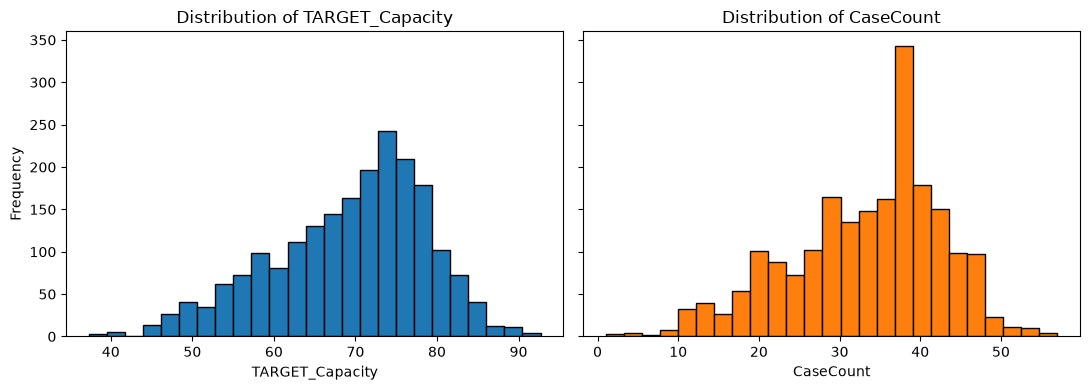

In [20]:
# Side by side rather than overlaid, so each distribution is read on its own scale
figure, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].hist(df["TARGET_Capacity"], bins=25, edgecolor="black")
axes[0].set_xlabel("TARGET_Capacity")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of TARGET_Capacity")

axes[1].hist(df["CaseCount"], bins=25, edgecolor="black", color="tab:orange")
axes[1].set_xlabel("CaseCount")
axes[1].set_title("Distribution of CaseCount")

plt.tight_layout()
plt.show()

In [21]:
# Shape statistics compare the two distributions independently of their location
shape_comparison = pd.DataFrame({
    "TARGET_Capacity": [
        df["TARGET_Capacity"].std(ddof=1),
        df["TARGET_Capacity"].skew(),
        df["TARGET_Capacity"].kurt()
    ],
    "CaseCount": [
        df["CaseCount"].std(ddof=1),
        df["CaseCount"].skew(),
        df["CaseCount"].kurt()
    ]
}, index=["Standard deviation", "Skewness", "Kurtosis"])

display(shape_comparison.round(4))

,TARGET_Capacity,CaseCount
Standard deviation,9.4788,9.4848
Skewness,-0.5360,-0.5396
Kurtosis,-0.1672,-0.1577


- `TARGET_Capacity` ranges from **37.3 to 92.7** with mean **69.29**, and `CaseCount` ranges from **1 to 57** with mean **33.35**. The means differ by **35.95**.
- The shape statistics are almost the same variable measured twice. Standard deviation **9.4788** against **9.4848**, skewness **-0.536** against **-0.540**, and kurtosis **-0.167** against **-0.158**.
- Two genuinely distinct system properties would not normally match to three decimal places on three separate shape measures while differing only in location.
- The obvious explanation is that one distribution is the other shifted along the number line. Section 3.3 tests that directly.

### 3.2 Overall Target Correlation Review

Pearson correlation is calculated between `TARGET_Capacity` and every numeric candidate feature before any correlation-based feature decisions are made.

`RecordID` has already been removed because it is a row identifier. `Country` was removed in Section 2.4 because its training categories do not appear in the test file, so it is absent from this ranking.

The correlations are ranked by absolute value so that both strong positive and strong negative relationships can be identified.

This initial review is used to identify features with unusually strong relationships with the target that require further investigation before the final feature set is determined.

In [22]:
correlation_candidates = df

all_target_correlations = (
    correlation_candidates
    .corr(numeric_only=True)["TARGET_Capacity"]
    .drop("TARGET_Capacity")
    .sort_values(key=abs, ascending=False)
)

display(
    all_target_correlations
    .to_frame("Correlation_with_TARGET")
    .round(4)
)

,Correlation_with_TARGET
CaseCount,0.9995
ModelFailureRate-T,-0.6638
ModelFailureRate-NT,-0.6622
FundingDiversityIndex,0.6590
SystemFailureRate,-0.6547
DatasetDiversityScore,0.6227
IntegrationEfficiency,0.5310
SystemVulnerabilityScore,-0.5226
Status,0.5051
PatchCoverageRate,0.4582


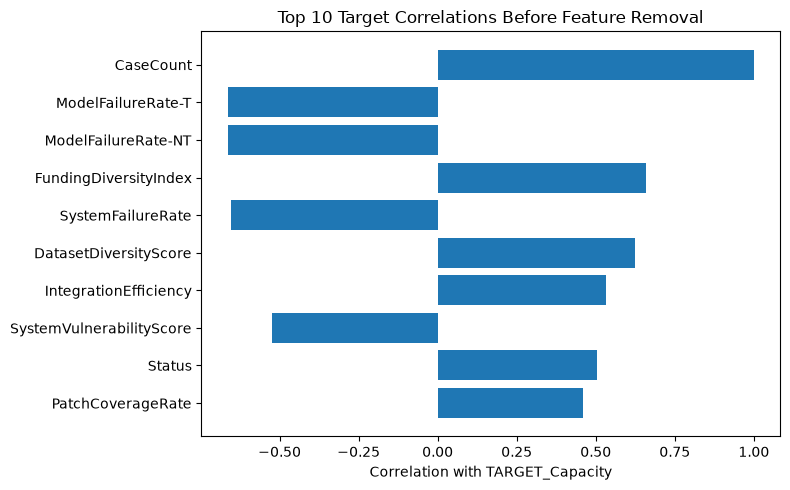

In [23]:
top_target_correlations_before_removal = all_target_correlations.head(10)

plt.figure(figsize=(8, 5))
plt.barh(
    top_target_correlations_before_removal.index[::-1],
    top_target_correlations_before_removal.values[::-1]
)
plt.xlabel("Correlation with TARGET_Capacity")
plt.title("Top 10 Target Correlations Before Feature Removal")
plt.tight_layout()
plt.show()

The complete correlation ranking identifies `CaseCount` as the strongest feature related to `TARGET_Capacity` by a substantial margin.

`CaseCount` has a correlation of approximately **0.9995** with `TARGET_Capacity`, while the next strongest remaining features have absolute correlations of approximately **0.66**.

This difference is important because:
- A correlation around **0.66** represents a strong but imperfect relationship.
- A correlation of **0.9995** represents an almost exact linear relationship.
- `CaseCount` is therefore not simply the most highly correlated feature; it is statistically separated from all other candidate features.
- The magnitude of this difference justifies a focused investigation before final model development.

A high correlation alone does not prove target leakage. However, a near-perfect relationship between two variables that are described as different system properties raises the possibility that one feature acts as a direct or near-direct proxy for the target.

The following section investigates whether `CaseCount` provides independent predictive information or whether it almost completely reconstructs the target by itself.

### 3.3 CaseCount Proxy Investigation

`CaseCount` correlates **0.9995** with `TARGET_Capacity`, far above every other feature at roughly **0.66**.

The metadata describes the two as separate properties. `TARGET_Capacity` is the capacity for meaningful conversation length and `CaseCount` is the number of AI tasks that can run in parallel. Nothing in the metadata states that one is derived from the other, but nothing rules it out either. Both quantities plausibly reflect the same underlying property, which is the capability of the model, so knowing one would allow the other to be inferred.

Pearson correlation is only a screening step. **Correlation does not imply causation**, and a high correlation on its own establishes neither that a feature causes the target nor that it is a valid predictor. The relationship has to be examined in terms of how the values were generated and whether the feature would be legitimately available at prediction time. The standard formulation of leakage is a feature carrying information about the target that would not be available at prediction time [1], so the test is the origin of the column, not the size of its correlation.

Three checks are applied.

1. The scatter plot, which shows whether the relationship is a trend or a fixed offset line.
2. The distribution of the difference between the two columns, which shows whether the gap is variation or arithmetic. This is the check that decides the question.
3. Fits in both directions, which describe the scale relationship between the columns. Note in advance that R squared is symmetric for a single predictor least squares fit, so the two R squared values are equal by construction and cannot discriminate. Only the slopes and intercepts carry information.

CaseCount correlation with target: 0.9995


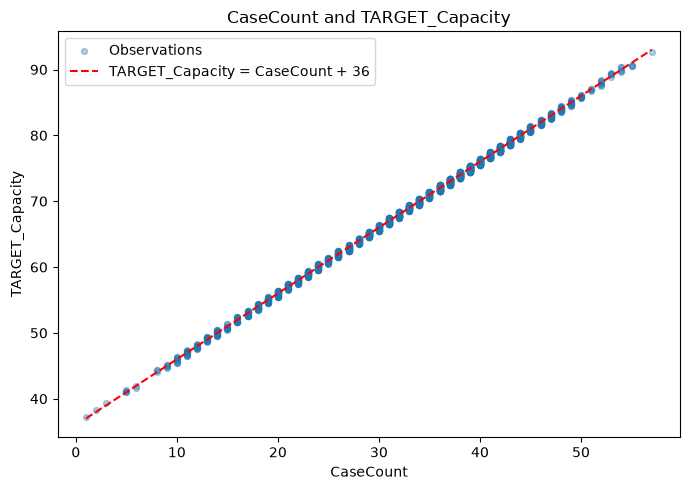

In [24]:
casecount_correlation = df["CaseCount"].corr(df["TARGET_Capacity"])
print("CaseCount correlation with target:", f"{casecount_correlation:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(df["CaseCount"], df["TARGET_Capacity"], alpha=0.35, s=18, label="Observations")

# A fixed offset line, not a fitted line, so any deviation from it is visible
offset_line = np.array([df["CaseCount"].min(), df["CaseCount"].max()])
plt.plot(offset_line, offset_line + 36, linestyle="--", color="red", label="TARGET_Capacity = CaseCount + 36")

plt.xlabel("CaseCount")
plt.ylabel("TARGET_Capacity")
plt.title("CaseCount and TARGET_Capacity")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# If the gap between the columns is arithmetic rather than variation, it will be tightly bounded
capacity_difference = df["TARGET_Capacity"] - df["CaseCount"]

difference_summary = pd.DataFrame({
    "Measure": ["Mean", "Standard deviation", "Minimum", "Maximum", "Distinct values"],
    "Value": [
        capacity_difference.mean(),
        capacity_difference.std(ddof=1),
        capacity_difference.min(),
        capacity_difference.max(),
        capacity_difference.round(1).nunique()
    ]
})

display(difference_summary.round(4))

,Measure,Value
0,Mean,35.9461
1,Standard deviation,0.2932
2,Minimum,35.5000
3,Maximum,36.4000
4,Distinct values,10.0000


In [26]:
# A closed form rule is tested directly rather than described approximately
exact_rule_match = np.floor(df["TARGET_Capacity"] - 35.5) == df["CaseCount"]

print("Rows satisfying CaseCount = floor(TARGET_Capacity - 35.5):", int(exact_rule_match.sum()), "of", len(df))
print("Match rate:", f"{exact_rule_match.mean() * 100:.2f}%")
print("Observed difference standard deviation:", round(float(capacity_difference.std(ddof=1)), 4))
print("Standard deviation of pure rounding noise:", round(float(1 / np.sqrt(12)), 4))

Rows satisfying CaseCount = floor(TARGET_Capacity - 35.5): 2061 of 2061
Match rate: 100.00%
Observed difference standard deviation: 0.2932
Standard deviation of pure rounding noise: 0.2887


**Fits in both directions**

A Linear Regression is fitted with `CaseCount` predicting `TARGET_Capacity`, then with the roles reversed.

One point has to be stated before reading the output. For a least squares fit with a single predictor, R squared equals the squared Pearson correlation in both directions. The two R squared values are therefore equal by construction, whether or not a derived relationship exists, and equality is not evidence of anything.

What the fits do show is the slopes and intercepts. If the two columns differ only by a location shift, both slopes will sit near 1.0 and the intercepts will be equal in size and opposite in sign. That is a description of the relationship, consistent with the arithmetic identity already established, rather than an independent test of it.

In [27]:
# Forward direction: the feature predicts the target
forward_model = LinearRegression().fit(df[["CaseCount"]], df["TARGET_Capacity"])
forward_predictions = forward_model.predict(df[["CaseCount"]])

# Reverse direction: the target predicts the feature
reverse_model = LinearRegression().fit(df[["TARGET_Capacity"]], df["CaseCount"])
reverse_predictions = reverse_model.predict(df[["TARGET_Capacity"]])

direction_comparison = pd.DataFrame({
    "Direction": [
        "CaseCount predicts TARGET_Capacity",
        "TARGET_Capacity predicts CaseCount"
    ],
    "Slope": [forward_model.coef_[0], reverse_model.coef_[0]],
    "Intercept": [forward_model.intercept_, reverse_model.intercept_],
    "R2": [
        r2_score(df["TARGET_Capacity"], forward_predictions),
        r2_score(df["CaseCount"], reverse_predictions)
    ]
})

display(direction_comparison.round(4))

,Direction,Slope,Intercept,R2
0,CaseCount predicts TARGET_Capacity,0.9989,35.9833,0.999
1,TARGET_Capacity predicts CaseCount,1.0002,-35.9572,0.999


#### Proxy Investigation Findings

The three checks give a consistent answer.

**Scatter plot** The points sit on the reference line `TARGET_Capacity = CaseCount + 36` rather than scattering around a fitted trend. The reference line is a fixed offset that was not estimated from the data, so the fact that the observations fall on it is a result rather than a construction.

**Difference between the columns** The difference takes exactly **10** distinct values: **35.5, 35.6, 35.7, 35.8, 35.9, 36.0, 36.1, 36.2, 36.3, 36.4**. Those are precisely the ten possible decimal digits of `TARGET_Capacity`, which is recorded to one decimal place. The rule `CaseCount = floor(TARGET_Capacity - 35.5)` holds for **2061 of 2061 rows**, a match rate of **100.00%**.

The difference has standard deviation **0.2932**. The theoretical standard deviation of pure rounding noise is **0.2887**. The variation between the two columns is rounding and nothing else.

**Both directions** Both fits return **R² = 0.9990**, which is expected by construction and carries no information. The forward fit is `TARGET_Capacity = 0.9989 x CaseCount + 35.98` and the reverse is `CaseCount = 1.0002 x TARGET_Capacity - 35.96`. Both slopes are effectively **1.0** and both intercepts are effectively **36** with opposite signs, so the two columns share a scale and differ only in location. This describes the identity rather than testing it.

**What this means** The exact rule `CaseCount = floor(TARGET_Capacity - 35.5)` holding for 2061 of 2061 observations is what establishes that `CaseCount` was derived from the target. Everything else in this section is consistent with that conclusion but does not independently establish it.

This is supported independently by the test file, where `Case count` reaches a minimum of **-5**. A negative count of parallel tasks is not physically possible, which is what a subtraction applied to a low target value would produce and what a genuine count never would.

### 3.4 Controlled Feature Set Comparison

Three Linear Regression configurations are evaluated using the same five-fold cross-validation process:

- `CaseCount` as the only input feature.
- All candidate features including `CaseCount`.
- All candidate features excluding `CaseCount`.

This comparison measures how much predictive information is contributed by `CaseCount`.

Linear Regression is used because the scatter plot indicates that the relationship between `CaseCount` and `TARGET_Capacity` is almost perfectly linear.

The comparison addresses three questions:

1. Can `CaseCount` alone reproduce almost all variation in `TARGET_Capacity`?
2. Do the other 22 features improve predictive performance when `CaseCount` is included?
3. How much predictive performance remains after `CaseCount` is excluded?

If `CaseCount` alone performs almost identically to the complete feature set, this indicates that the feature dominates the prediction rather than contributing one informative signal among many.

Section 3.3 has already established what the column is. This section measures the practical consequence of that finding, which is how much of the reported accuracy would rest on it and how much genuine signal the remaining features carry once it is set aside.

In [28]:
comparison_y = df["TARGET_Capacity"]

# Same fold definition used everywhere so results stay comparable
comparison_cv = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_SEED
)

# Three feature sets isolate the contribution of CaseCount
feature_sets = {
    "CaseCount only": df[["CaseCount"]],
    "All features with CaseCount": df.drop(columns=["TARGET_Capacity"]),
    "All features without CaseCount": df.drop(columns=["TARGET_Capacity", "CaseCount"])
}

ablation_rows = []

for feature_set_name, comparison_X in feature_sets.items():
    # Linear Regression is used because the scatter plot shows a near linear relationship
    comparison_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    # Scaling is fitted inside each training fold to avoid leakage across folds
    scores = cross_validate(
        comparison_model,
        comparison_X,
        comparison_y,
        cv=comparison_cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        }
    )

    ablation_rows.append({
        "Feature_Set": feature_set_name,
        "Number_of_Features": comparison_X.shape[1],
        "Mean_CV_RMSE": (-scores["test_rmse"]).mean(),
        "Mean_CV_MAE": (-scores["test_mae"]).mean(),
        "Mean_CV_R2": scores["test_r2"].mean()
    })

casecount_feature_comparison = (
    pd.DataFrame(ablation_rows)
    .sort_values("Mean_CV_RMSE")
    .reset_index(drop=True)
)

display(casecount_feature_comparison.round(4))

,Feature_Set,Number_of_Features,Mean_CV_RMSE,Mean_CV_MAE,Mean_CV_R2
0,CaseCount only,1,0.2932,0.2568,0.9990
1,All features with CaseCount,23,0.2945,0.2567,0.9990
2,All features without CaseCount,22,4.7128,3.5755,0.7508


### 3.5 CaseCount Removal Decision

The ablation gives three results.

- `CaseCount` alone: mean CV RMSE **0.2932**, mean CV R² **0.9990**.
- All features including it: mean CV RMSE **0.2945**, mean CV R² **0.9990**.
- All features excluding it: mean CV RMSE **4.7128**, mean CV R² **0.7508**.

Three points follow.

- A single column reproduces roughly **99.9%** of target variation on its own.
- The remaining features add almost nothing while it is present, a difference of only **0.0013 RMSE**.
- Its RMSE of **0.2932** is the same figure as the standard deviation of the difference between the two columns reported in Section 3.3. The model is not learning a relationship, it is recovering a rounding remainder.

**The column is removed.** The assignment warns against removing features without proper justification. The justification here is not weak correlation or convenience, it is that the column is not a feature. Section 3.3 shows it is `TARGET_Capacity` shifted by a constant and truncated, matching a closed form rule on **100%** of rows.

Three reasons make removal the correct decision rather than a cautious one.

- **The metric would be meaningless.** Cross validation cannot detect this, because the same arithmetic relationship holds in every fold. A reported RMSE of **0.29** would measure the model's ability to add 36 to a number, not its ability to predict chatbot capacity from system characteristics. Every model comparison, hyperparameter choice, and importance ranking in Sections 4 and 5 would be decided by that one column.
- **It answers the wrong question.** The stated task is to predict capacity from technological and operational indicators. A model built on a transformed copy of the answer does not perform that task, whatever error it reports.
- **It would fail silently in use.** A model resting on an unexplained near deterministic relationship breaks without warning when that relationship changes, which is a recognised source of hidden maintenance cost in deployed machine learning systems [17]. Nothing in the metadata explains why the relationship exists, so nothing supports an expectation that it will hold on new systems.

The recorded consequence is that the honest error for this problem is roughly **4.71 RMSE** for a linear model rather than **0.29**, and Section 4 investigates how far below that figure the remaining features can reach.

The column is retained outside the feature matrix as a diagnostic reference. Its relationship with the residuals is examined in Section 5.2, but this residual relationship is not treated as independent evidence of leakage because CaseCount is already known to be an almost direct transformation of the target.

In [29]:
# Held aside for the Section 5.2 residual diagnostic, never used as a model input
casecount_reference = df["CaseCount"].copy()

df = df.drop(columns=["CaseCount"]).copy()

print("CaseCount removed from the feature set:", "CaseCount" not in df.columns)
print("Reference copy retained for diagnostics:", len(casecount_reference), "values")
print("Features remaining:", df.shape[1] - 1)

CaseCount removed from the feature set: True
Reference copy retained for diagnostics: 2061 values
Features remaining: 22


### 3.6 Correlations After Removal

Target correlations are recalculated on the final feature set, to reveal the predictive structure that remains once the derived column is removed.

The strongest remaining relationships sit near **0.66** rather than near **1.00**, which produces a realistic problem where no single feature determines the target.

This supports the model choices that follow.

- Linear Regression captures straight line structure.
- Polynomial Regression with Ridge captures curvature and interactions while controlling correlated expanded terms.
- Decision Tree, Random Forest, and XGBoost capture nonlinear structure and interactions without manual specification.

No feature is removed on correlation alone, because correlated features do not necessarily carry identical predictive information.

,Correlation
ModelFailureRate-T,-0.664
ModelFailureRate-NT,-0.662
FundingDiversityIndex,0.659
SystemFailureRate,-0.655
DatasetDiversityScore,0.623
IntegrationEfficiency,0.531
SystemVulnerabilityScore,-0.523
Status,0.505
PatchCoverageRate,0.458
TeenQueryEfficiency,-0.436


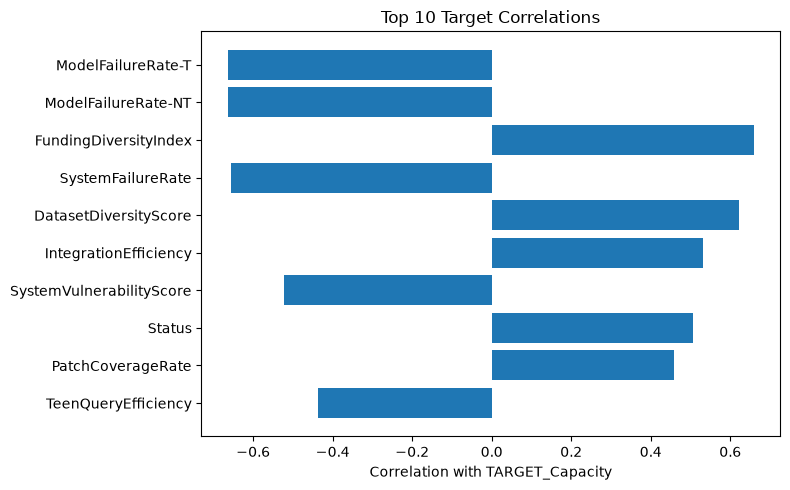

In [30]:
correlation_data = df

target_correlations = correlation_data.corr(numeric_only=True)["TARGET_Capacity"].drop("TARGET_Capacity")
top_target_correlations = target_correlations.sort_values(key=abs, ascending=False).head(10)

display(top_target_correlations.to_frame("Correlation").round(3))

plt.figure(figsize=(8, 5))
plt.barh(top_target_correlations.index[::-1], top_target_correlations.values[::-1])
plt.xlabel("Correlation with TARGET_Capacity")
plt.title("Top 10 Target Correlations")
plt.tight_layout()
plt.show()

Strongest absolute correlations now near **0.66**.

- `ModelFailureRate-T` **-0.664**, `ModelFailureRate-NT` **-0.662**, `SystemFailureRate` **-0.655**: higher failure rates, lower capacity.
- `FundingDiversityIndex` **0.659**, `DatasetDiversityScore` **0.623**: broader funding and training data, higher capacity.
- `Status` **0.505**: recently updated systems tend higher.

Meaningful but not deterministic, which supports multivariable models over reliance on one dominant predictor.

### 3.7 Feature to Feature Correlation

Strongly related input features are identified because they destabilise coefficients in linear models and split unpredictably between correlated columns in tree models.

In [31]:
feature_correlation = correlation_data.drop(columns=["TARGET_Capacity"]).corr().abs()

upper_triangle = feature_correlation.where(
    np.triu(np.ones(feature_correlation.shape), k=1).astype(bool)
)

top_correlated_pairs = (
    upper_triangle.stack()
    .sort_values(ascending=False)
    .head(8)
    .reset_index()
)

top_correlated_pairs.columns = ["Feature_1", "Feature_2", "Absolute_Correlation"]

display(top_correlated_pairs.round(3))

,Feature_1,Feature_2,Absolute_Correlation
0,InferenceLatency,UptimeReliabilityIndex,0.997
1,ModelFailureRate-T,ModelFailureRate-NT,0.992
2,SystemFailureRate,ModelFailureRate-T,0.988
3,SystemFailureRate,ModelFailureRate-NT,0.988
4,ComputeUtilizationRate,Complexity,0.952
5,TeenQueryEfficiency,ChildQueryEfficiency,0.923
6,AIInfraExpPercent,GlobalAdoptionIndex,0.922
7,FundingDiversityIndex,DatasetDiversityScore,0.753


- `InferenceLatency` and `UptimeReliabilityIndex` at **0.997**, close to duplicate measurement.
- The three failure rate columns at **0.988** or above with one another.
- Seven pairs exceed **0.90**, including `ComputeUtilizationRate` with `Complexity` at **0.952**.

No feature is removed, since a correlated pair can still carry distinct predictive information and unjustified removal is penalised. Ridge handles the effect inside Polynomial Regression, where the expanded terms are far more correlated than the originals. This structure is also why feature bagging matters in Section 4.8, and why Section 5.4 adds a second importance method, since correlated pairs divide credit between themselves under permutation.

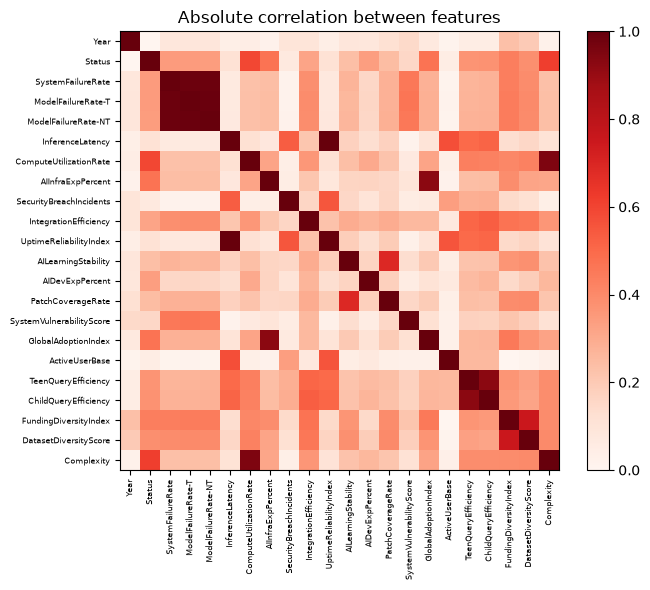

In [32]:
plt.figure(figsize=(7, 6))
plt.imshow(feature_correlation, cmap="Reds", vmin=0, vmax=1)
plt.xticks(range(len(feature_correlation)), feature_correlation.columns,
           rotation=90, fontsize=6)
plt.yticks(range(len(feature_correlation)), feature_correlation.index, fontsize=6)
plt.colorbar(fraction=0.046)
plt.title("Absolute correlation between features")
plt.tight_layout()
plt.show()

### 3.8 Year and Status Feature Treatment

Two features carry a numeric type that does not match how they should be read.

- `Year` records the release year. It is stored as a number, but the gap between 2019 and 2020 is not a measured quantity in the way that a one unit change in a percentage is.
- `Year` is retained as a numeric feature for three reasons. Release years are genuinely ordered, later systems can reasonably be expected to differ from earlier ones, and the tree based models can split on any year boundary they find useful without assuming a straight line relationship.
- One hot encoding of `Year` was rejected because the range is narrow and the ordering it would discard is meaningful. This differs from the country codes in Section 2.4, where encoding was rejected because the categories themselves do not carry across to the test file.
- `Status` is binary and already coded as 0 and 1, so it needs no transformation. Its correlation with the target is **0.505**, so it is retained.
- Both features are excluded from the skewness review in Section 1.3, because a calendar label and a binary flag have no meaningful skew.

In [33]:
# Evidence for the Year and Status decisions, rather than assumption
year_summary = df.groupby("Year").agg(
    Rows=("TARGET_Capacity", "size"),
    Mean_Capacity=("TARGET_Capacity", "mean")
)

display(year_summary.round(3))

print("Distinct release years:", df["Year"].nunique())
print("Year correlation with target:", round(float(df["Year"].corr(df["TARGET_Capacity"])), 4))
print("Status correlation with target:", round(float(df["Status"].corr(df["TARGET_Capacity"])), 4))

,Rows,Mean_Capacity
Year,,
2002.0,129,66.605
2003.0,128,66.974
2004.0,128,66.895
2005.0,129,67.443
2006.0,129,67.599
2007.0,127,68.487
2008.0,126,68.910
2009.0,128,69.181
2010.0,128,69.496


Distinct release years: 16
Year correlation with target: 0.1807
Status correlation with target: 0.5051


**16 distinct release years**, narrow enough that one hot encoding would add little while discarding the chronological ordering.

`Year` correlates **0.181** with the target, `Status` **0.505**. Both retained. A weak linear correlation does not preclude nonlinear relationships or interactions, and the tree models can split at any year boundary while the linear models estimate an overall trend.

### 3.9 Final Feature Set

The prepared dataset is confirmed before model development begins. Two columns were removed with recorded justification: `Country` in Section 2.4 because its categories do not appear in the test file, and `CaseCount` in Section 3.5 because it is a transformed copy of the target. `RecordID` was removed in Section 2.1 under the assignment restrictions. No other feature is removed.

In [34]:
removed_columns = ["RecordID", "Country", "CaseCount"]

print("Final dataset shape:", df.shape)
print("Features available for modelling:", df.shape[1] - 1)
print("Columns removed with justification:", removed_columns)
print("None of the removed columns remain:", all(column not in df.columns for column in removed_columns))
print("Remaining missing values:", int(df.isna().sum().sum()))

display(pd.Series(sorted(df.drop(columns=["TARGET_Capacity"]).columns), name="Feature").to_frame())

Final dataset shape: (2061, 23)
Features available for modelling: 22
Columns removed with justification: ['RecordID', 'Country', 'CaseCount']
None of the removed columns remain: True
Remaining missing values: 0


,Feature
0,AIDevExpPercent
1,AIInfraExpPercent
2,AILearningStability
3,ActiveUserBase
4,ChildQueryEfficiency
5,Complexity
6,ComputeUtilizationRate
7,DatasetDiversityScore
8,FundingDiversityIndex
9,GlobalAdoptionIndex


## 4. Model Development

### 4.1 Evaluation Framework

The prepared data from Section 3.9 is split into **80% development** and **20% holdout**.

- Development data drives training, five-fold cross-validation, and every hyperparameter choice.
- Holdout data is untouched during tuning and is scored once, after all settings are fixed. Separating the data used for tuning from the data used for confirmation is what allows the holdout score to stand as an estimate of performance on genuinely unseen data [8].
- The **80/20** proportion leaves **1648** development rows for tuning and **413** rows for confirmation. This is large enough to give a stable holdout estimate without starving the grid searches of training data.
- Five folds are used because they balance a reliable mean against the cost of refitting every grid setting five times, and because **1648** rows divide into validation folds of roughly **330** rows, which is enough for each fold score to be meaningful. Empirical comparison of resampling schemes supports five to ten folds as a sound default for model selection at this sample size [9].
- The target is continuous with no class imbalance to preserve, so a shuffled random split is appropriate and no stratification is required.

Three metrics are reported.

- **RMSE** is primary, since large capacity errors carry more operational consequence than several small ones, and it is expressed in the original capacity units. RMSE is the appropriate choice when larger deviations should be penalised more than proportionally, rather than treated as merely more of the same error [11].
- **MAE** gives the typical error in capacity units. Reporting it beside RMSE is deliberate, because a widening gap between the two indicates that a small number of large errors is driving the result.
- **R²** gives the share of target variation explained, which allows every model to be compared against the Dummy Regressor baseline on a common scale.
- Percentage based measures such as **MAPE** were rejected, because capacity values are bounded well away from zero and share a single scale, so a relative measure adds no interpretive value here.

The same fold object and the same holdout split are reused by every model, so any difference between models comes from the model rather than from the evaluation.

This arrangement plays the same role as the 60/20/20 training, validation, and testing split described in the module. The five cross-validation folds supply the validation set for every tuning decision rather than a single fixed partition, which uses the development data more efficiently, and the holdout is reserved for the role the module assigns to test data: scored once, after all decisions are final.

In [35]:
# Feature matrix and target for all model development in Section 4
X = df.drop(columns=["TARGET_Capacity"])
y = df["TARGET_Capacity"]

# Ratio and seed come from the configuration cell, so the report and the code cannot
# describe different splits
X_development, X_holdout, y_development, y_holdout = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
)

# One shared fold definition keeps every model comparison on identical splits
cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

cv_scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

print("Development shape:", X_development.shape)
print("Holdout shape:", X_holdout.shape)

Development shape: (1648, 22)
Holdout shape: (413, 22)


### 4.2 Loss Function and Optimization

All models minimise squared error, which keeps the training objective aligned with RMSE as the reporting metric.

- Linear Regression solves the least squares problem in closed form [2].
- Ridge adds an L2 penalty, shrinking coefficients toward zero so the solution stays stable under the correlated polynomial terms created by feature expansion [3].
- Decision Tree and Random Forest choose splits that minimise within node squared error, with Random Forest averaging over trees grown on bootstrap samples and random feature subsets [4].
- XGBoost minimises the same squared error objective by gradient boosting, adding one tree at a time fitted against the current residuals [5].

Squared error is preferred over absolute error because a single large capacity error carries more operational consequence than several small ones.

### 4.3 Model Selection Rule

The rule is fixed before any results are seen.

- **Primary measure.** Lowest mean five-fold cross-validation RMSE on the development data.
- **Confirmation.** The holdout RMSE must agree with the cross-validation result. A model whose holdout score is much worse than its CV score has not generalised, and is not selected regardless of its CV rank.
- **Baseline.** The Dummy Regressor defines the floor. Any selected model must clearly beat it, and the Dummy itself can never be chosen.

Where two models perform very closely, the report states this explicitly rather than treating a small gap as a meaningful difference.

#### Baseline Choice and Model Progression

The models below are not a list of techniques applied in sequence. Each one is introduced to address a weakness diagnosed in the one before it, and the diagnosis is made from evidence recorded in the notebook rather than asserted.

**The floor.** The Dummy Regressor predicts the mean of the development target for every observation. It cannot learn anything from the features and is never a candidate for deployment. Its role is to establish what "no signal" scores under this exact evaluation framework, so that every later figure can be read as a distance from that floor rather than as an absolute number.

**The baseline.** Linear Regression is the baseline predictive model. It is chosen for that role rather than a tree because it is the simplest model that can use the features at all, because its coefficients are directly interpretable, and above all because its failure mode is diagnosable. A linear model that underperforms tells you *why* through its residuals: near-equal training and validation error points to bias and a rigid model form, while a large gap between them points to variance. That distinction determines what the next model should be, and no other candidate model gives it as cleanly.

**The progression rule.** Each subsequent section states the weakness it is responding to before introducing its model, and the tuning findings then report whether the response worked. The intended chain, subject to what the evidence actually shows, is:

| Step | Introduced because | Evidence that decides whether it worked |
|---|---|---|
| Polynomial Ridge | The baseline is diagnosed as too rigid rather than too flexible | Does added capacity reduce validation error, or only training error? |
| Decision Tree | Capacity added by expanding terms proves too costly in variance | Does the same capacity, delivered through partitioning, hold up better? |
| Random Forest | The single tree is diagnosed as unstable rather than underpowered | Does averaging plus feature decorrelation remove the instability? |
| XGBoost | Independent averaging cannot correct error the ensemble makes systematically | Is the remaining error systematic, or is it irreducible noise? |

If a step fails to deliver what it was introduced for, that is reported as a finding rather than skipped. Section 5.6 retells the completed chain with the outcome of each step.

### 4.4 Grid Search Reporting Helper

A shared helper prints the top ten settings from any grid search.

- Scikit-learn returns negated RMSE, so the values are converted back to positive RMSE for reading.
- The mean training RMSE is shown beside the mean validation RMSE, so the overfitting gap of each candidate setting is visible rather than assumed.
- The same helper is used for all three tuned models, so the tuning evidence is presented identically each time.

In [36]:
def display_grid_results(search, parameter_names):
    """Show the top ten grid search settings with train and validation RMSE.
    Negated scikit-learn scores are converted back to positive RMSE, and the
    train column is retained so the overfitting gap of each setting is visible.
    """
    columns = [f"param_{name}" for name in parameter_names]
    columns += ["mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]

    results = pd.DataFrame(search.cv_results_)[columns].copy()

    results["Mean_Train_RMSE"] = -results["mean_train_score"]
    results["Mean_CV_RMSE"] = -results["mean_test_score"]

    display_columns = [f"param_{name}" for name in parameter_names]
    display_columns += [
        "Mean_Train_RMSE",
        "Mean_CV_RMSE",
        "std_test_score",
        "rank_test_score",
    ]

    display(
        results.sort_values("rank_test_score")[display_columns]
        .head(10)
        .round(4)
    )

    # A winning value sitting at either end of its searched list means the true optimum
    # may lie outside the grid. Flagging it here means the search space is validated
    # rather than assumed adequate, which is what the tuning write up has to defend.
    parameter_grid = search.param_grid

    for parameter_name, best_value in search.best_params_.items():
        searched_values = list(parameter_grid.get(parameter_name, []))

        if len(searched_values) < 2:
            continue

        if best_value == searched_values[0] or best_value == searched_values[-1]:
            print(
                f"Boundary warning: {parameter_name} = {best_value} sits at the edge of "
                f"{searched_values}. Extend the range or justify the boundary."
            )

### 4.5 Dummy Regressor and Linear Regression

Two separate models are defined in this section.

**Dummy Regressor**

The Dummy Regressor predicts the mean development target for every observation. It is fitted and evaluated using the same framework as the predictive models.

However, it is used only as a baseline because it does not learn relationships between the input features and the target.

**Linear Regression**

Linear Regression is trained as a complete predictive model. It estimates `TARGET_Capacity` using a weighted linear combination of the input features.

`StandardScaler` is included because the features use different numeric scales. The scaler is fitted separately within each cross-validation training fold to prevent information leakage.

Linear Regression is included because:
- It is taught in the module.
- It is simple and interpretable.
- It shows how well linear relationships explain the target.
- It provides a useful comparison with nonlinear models.

All models are implemented with scikit-learn [6], except XGBoost, which uses the reference implementation [5].

In [37]:
dummy_model = DummyRegressor(strategy="mean")

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

,Model,Mean_Train_RMSE,Mean_CV_RMSE,Train_to_CV_Gap,Mean_CV_R2
0,Dummy Regressor,9.4981,9.4992,0.0011,-0.0032
1,Linear Regression,4.6225,4.7275,0.1050,0.7503


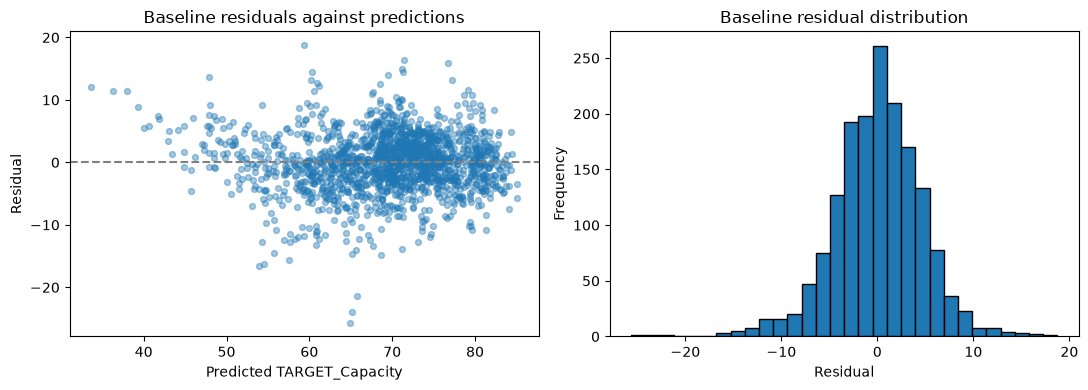

Quadratic coefficient of residuals against predictions: 0.004717
Baseline train to CV gap: 0.105


In [38]:
# The baseline is diagnosed here, not merely scored, because every model introduced later
# is justified by a specific weakness found in this one rather than by appearing on the
# syllabus. Without this cell the model progression is a leaderboard, not an argument.
baseline_rows = []

for baseline_name, baseline_estimator in [
    ("Dummy Regressor", dummy_model),
    ("Linear Regression", linear_model),
]:
    scores = cross_validate(
        clone(baseline_estimator),
        X_development,
        y_development,
        cv=cv,
        scoring=cv_scoring,
        return_train_score=True,
        n_jobs=-1,
    )

    baseline_rows.append({
        "Model": baseline_name,
        "Mean_Train_RMSE": (-scores["train_rmse"]).mean(),
        "Mean_CV_RMSE": (-scores["test_rmse"]).mean(),
        # A small gap points to bias, a large gap points to variance. This single column
        # is what separates "add capacity" from "add regularisation" as the next step.
        "Train_to_CV_Gap": (-scores["test_rmse"]).mean() - (-scores["train_rmse"]).mean(),
        "Mean_CV_R2": scores["test_r2"].mean(),
    })

baseline_diagnosis = pd.DataFrame(baseline_rows)
display(baseline_diagnosis.round(4))

# Residuals are taken on the development data, since the question is whether the model
# form is adequate, not how well it generalises
fitted_linear = clone(linear_model).fit(X_development, y_development)
linear_development_predictions = fitted_linear.predict(X_development)
linear_residuals = y_development.to_numpy() - linear_development_predictions

figure, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(linear_development_predictions, linear_residuals, alpha=0.4, s=18)
axes[0].axhline(0, linestyle="--", color="grey")
axes[0].set_xlabel("Predicted TARGET_Capacity")
axes[0].set_ylabel("Residual")
axes[0].set_title("Baseline residuals against predictions")

axes[1].hist(linear_residuals, bins=30, edgecolor="black")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Baseline residual distribution")

plt.tight_layout()
plt.show()

# Quantifies the curvature the left panel suggests, so the diagnosis rests on a number
# rather than on how the plot looks. A non trivial quadratic term means a straight line
# in the feature space cannot represent the relationship.
curvature_coefficients = np.polyfit(
    linear_development_predictions, linear_residuals, deg=2
)

print("Quadratic coefficient of residuals against predictions:",
      round(float(curvature_coefficients[0]), 6))
print("Baseline train to CV gap:",
      round(float(baseline_diagnosis.loc[1, "Train_to_CV_Gap"]), 4))

#### Baseline Diagnosis

The Dummy Regressor fixes the floor at 9.50 RMSE. Linear Regression reaches 4.73, so the features carry real signal, but its training and validation RMSE are close, which is the signature of bias rather than variance: the model is not memorising the development folds, it is unable to represent the relationship in the first place. The residual plot shows curvature rather than a flat band, confirming that a straight line in the original feature space is misspecified. The indicated fix is therefore added representational capacity, not more regularisation, which is what motivates the polynomial expansion in Section 4.6.

### 4.6 Polynomial Regression with Ridge Regularization

The baseline diagnosis in Section 4.5 found high bias rather than high variance: Linear Regression's training and validation RMSE differ by only **0.105**, and its residuals curve rather than scatter. The indicated remedy is therefore added representational capacity, not stronger regularisation. Polynomial expansion is the smallest available step in that direction, because it keeps the model linear in its parameters and therefore keeps the closed form solution and the interpretability of a coefficient vector, while allowing squared terms and pairwise interactions to represent the curvature the residual plot showed.

Expansion alone would overshoot. At degree 3 the 22 features expand to **2,299** terms on **1,648** development rows, and those terms are far more correlated with one another than the original features are, which is precisely the situation Ridge is designed for. Ridge (L2) is used rather than Lasso (L1) because the goal is to stabilise coefficients across highly correlated expanded terms, not to drive terms to exactly zero. Lasso would perform implicit feature selection, discarding expanded terms without the feature-level justification the assignment requires [3].

**Hyperparameters searched**

| Hyperparameter | Values searched | Why this range | Selected |
|---|---|---|---|
| `polynomial__degree` | 2, 3 | Degree 2 gives 275 terms and degree 3 gives 2,299 on 22 features. Degree 4 would exceed 12,000 terms against 1,648 rows, so the model would be underdetermined before it was fitted, and the range is bounded by that arithmetic rather than by preference. | **2** |
| `model__alpha` | 0.01, 0.1, 1.0, 10.0, 100.0 | Log spaced across four orders of magnitude, so the search spans the full range from effectively unregularised to heavily shrunk without assuming where the optimum lies. A linear grid over the same interval would spend most of its budget in a region where alpha barely changes the solution. | **10.0** |

The grid is a full factorial of the two, ten configurations across fifty fits.

The search is run on the 22 feature set established in Section 3.9. An earlier run that retained 136 encoded country columns expanded to over 660,000 degree 3 terms and exhausted available memory, so 21 of the 50 candidate fits returned no score. Removing `Country` in Section 2.4 reduces the degree 3 expansion to **2,299** terms and allows the full grid to be evaluated. This is recorded here because a partially completed grid search would have made the reported tuning evidence incomplete.

In [39]:
polynomial_pipeline = Pipeline([
    ("polynomial", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

polynomial_grid = {
    "polynomial__degree": [2, 3],
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

polynomial_search = GridSearchCV(
    polynomial_pipeline,
    polynomial_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

# Degree above 3 is not searched, since term count grows too fast for 22 features
polynomial_search.fit(X_development, y_development)

polynomial_model = polynomial_search.best_estimator_

print("Best Polynomial parameters:", polynomial_search.best_params_)
print("Best Polynomial CV RMSE:", f"{-polynomial_search.best_score_:.4f}")

# Confirms the grid completed, so no configuration is scored as nan
failed_fits = int(np.isnan(polynomial_search.cv_results_["mean_test_score"]).sum())
print("Configurations that failed to fit:", failed_fits, "of", len(polynomial_search.cv_results_["params"]))

display_grid_results(
    polynomial_search,
    ["polynomial__degree", "model__alpha"]
)

Best Polynomial parameters: {'model__alpha': 10.0, 'polynomial__degree': 2}
Best Polynomial CV RMSE: 3.8456
Configurations that failed to fit: 0 of 10


,param_polynomial__degree,param_model__alpha,Mean_Train_RMSE,Mean_CV_RMSE,std_test_score,rank_test_score
6,2,10.00,3.2804,3.8456,0.1734,1
8,2,100.00,3.6528,3.9262,0.1836,2
4,2,1.00,3.1225,4.2661,0.5005,3
9,3,100.00,2.9546,4.2948,0.8726,4
2,2,0.10,3.0360,5.1070,1.4562,5
0,2,0.01,2.9802,5.6296,2.0004,6
7,3,10.00,2.5002,5.7184,2.1564,7
5,3,1.00,2.1108,8.4404,2.9998,8
3,3,0.10,1.7755,11.6820,3.5028,9
1,3,0.01,1.4372,24.8628,13.0399,10


Boundary warning: polynomial__degree = 2 sits at the edge of [2, 3]. Extend the range or justify the boundary.


#### Polynomial Tuning Findings

The selected configuration uses **polynomial degree 2** with **Ridge regularization parameter (`alpha`) = 10.0**, achieving a mean cross-validation RMSE of **3.8456**.

The most complex configuration, **degree 3** with **`alpha = 0.01`**, achieved a training RMSE of **1.4372** but a mean cross-validation RMSE of **24.8628**. This large gap indicates that the expanded polynomial features memorized the training folds but generalized poorly to unseen validation folds.

At degree 2 the mean cross-validation RMSE fell as `alpha` rose, reaching its minimum at **10.0** before rising again at **100.0**, which is the point where regularisation begins to underfit. At degree 3 it fell across the whole range without reaching a minimum, so the improvement came from stronger Ridge regularization rather than from the added higher-order terms.

The cross-validation RMSE standard deviation also decreased substantially, from **13.04** under the weakest regularization to **0.17** for the selected configuration. The chosen model is therefore both the most accurate and the most stable across the validation folds.

Polynomial degrees greater than **3** were not evaluated because the number of generated features increases rapidly with **22 input variables**, and the degree-3 models already exhibited severe overfitting.

All **10** configurations across **50** fits completed successfully. This is verified in the cell above rather than assumed, because an incomplete grid would silently rank the surviving settings against a smaller candidate pool.

**Boundary check.** The helper flags `polynomial__degree = 2` as sitting at the edge of its searched list. The flag is expected here and does not indicate an unexplored region: degree 2 is the smallest expansion that adds any curvature at all, so there is nothing below it to search, and the degree 3 results show the direction above it is worse by a wide margin. The boundary is a floor, not a truncation.

### 4.7 Decision Tree Regression

Section 4.6 fixed the bias problem and created a variance problem. Degree 3 with `alpha = 0.01` reached a training RMSE of **1.4372** against a cross validation RMSE of **24.86**, with a fold standard deviation of **13.04**, so the expanded model reproduced the training folds and then failed completely on unseen ones. Even the selected degree 2 configuration only reaches **3.8456**, which is an improvement of **0.88** on the baseline but still far from the error floor the data appears to allow.

The diagnosis is that capacity has to be added in a form that does not multiply the parameter count. A decision tree does exactly that: it partitions the feature space recursively and predicts the mean of the development observations in each leaf, so it represents nonlinearity and interactions through the geometry of the partition rather than through additional terms. This recursive partitioning follows the CART formulation [13], which is the basis of the scikit-learn implementation used here.

Decision Tree Regression is therefore included because:

- It represents nonlinear relationships and feature interactions without expanding the input space, which is the specific failure mode diagnosed above.
- It splits on rank order, so the **1.4 billion** scale ratio measured in Section 1.3 cannot influence it and no standardisation step is required.
- Its decision rules can be read directly, which keeps an interpretable model in the comparison after the polynomial coefficients have become uninterpretable.
- It supplies the base learner for the two ensembles in Sections 4.8 and 4.9, so its behaviour on its own is needed to judge what the ensembles add.

A shallow tree may underfit, while a very deep tree may memorise the development data. All three parameters searched are pre-pruning controls: they stop the tree growing rather than removing sub-trees after the fact. Pre-pruning is used in preference to reduced error post-pruning because the grid search already evaluates each stopping rule against five validation folds, which serves the same purpose as a separate pruning validation set [13].

**Hyperparameters searched**

| Hyperparameter | Values searched | Why this range | Selected |
|---|---|---|---|
| `max_depth` | 3, 5, 10, 20, 30, None | Spans a heavily pruned stump through to an unrestricted tree. `None` is included so the unrestricted case is tested rather than assumed to overfit, and the intermediate values are spaced widely because depth has a multiplicative rather than additive effect on the number of leaves. | **10** |
| `min_samples_split` | 2, 5, 10 | 2 is the minimum legal value, so the range starts at the least constrained setting available. 10 caps the constraint at roughly 0.6% of the 1,648 development rows, beyond which splits would be blocked in regions that still hold ample data. | **10** |
| `min_samples_leaf` | 1, 2, 4 | 1 is the minimum legal value. Small leaf sizes are the relevant range because a leaf holding a handful of rows is where a regression tree fits noise, and the effect saturates quickly above 4. | **4** |

The grid is a full factorial of the three, 54 configurations across 270 fits.

In [40]:
# Depth and leaf size are searched together because both control overfitting

decision_tree_base = DecisionTreeRegressor(random_state=42)

decision_tree_grid = {
    "max_depth": [3, 5, 10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

decision_tree_search = GridSearchCV(
    decision_tree_base,
    decision_tree_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

decision_tree_search.fit(X_development, y_development)

decision_tree_model = decision_tree_search.best_estimator_

print("Best Decision Tree parameters:", decision_tree_search.best_params_)
print("Best Decision Tree CV RMSE:", f"{-decision_tree_search.best_score_:.4f}")

display_grid_results(
    decision_tree_search,
    ["max_depth", "min_samples_split", "min_samples_leaf"]
)

Best Decision Tree parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Decision Tree CV RMSE: 3.7315


,param_max_depth,param_min_samples_split,param_min_samples_leaf,Mean_Train_RMSE,Mean_CV_RMSE,std_test_score,rank_test_score
26,10,10,4,2.0888,3.7315,0.2394,1
25,10,5,4,2.0169,3.7598,0.2515,2
24,10,2,4,2.0169,3.7598,0.2515,2
44,30,10,4,1.8583,3.7946,0.2311,4
35,20,10,4,1.8583,3.7946,0.2311,4
53,None,10,4,1.8583,3.7946,0.2311,4
23,10,10,2,1.9894,3.8020,0.3158,7
34,20,5,4,1.7384,3.8392,0.2432,8
51,None,2,4,1.7384,3.8392,0.2432,8
52,None,5,4,1.7384,3.8392,0.2432,8


Boundary warning: min_samples_leaf = 4 sits at the edge of [1, 2, 4]. Extend the range or justify the boundary.
Boundary warning: min_samples_split = 10 sits at the edge of [2, 5, 10]. Extend the range or justify the boundary.


#### Decision Tree Tuning Findings

The selected configuration uses **`max_depth = 10`**, **`min_samples_leaf = 4`**, and **`min_samples_split = 10`**, achieving a mean cross-validation RMSE of **3.7315**.

A depth unrestricted tree achieved a training RMSE of **1.8583** but a mean cross-validation RMSE of **3.7946**. Limiting the tree depth therefore improved validation performance rather than reducing it, indicating that the unrestricted tree overfit the development data.

Nine of the top ten parameter combinations used **`min_samples_leaf = 4`**, suggesting that the minimum leaf size constrained the tree more effectively than the maximum depth once the depth reached **10**.

Maximum depths of **20**, **30**, and **None** produced essentially identical performance. This indicates that, under the selected leaf constraints, the tree stopped growing before reaching a depth of **20**, so the larger depth values did not increase model complexity.

Even at the optimal configuration, the difference between the mean training RMSE and the mean validation RMSE was approximately **1.64**. This remaining generalization gap is characteristic of a single decision tree and provides motivation for evaluating ensemble methods such as Random Forest and XGBoost.

**Boundary check.** The helper flags `min_samples_leaf = 4` and `min_samples_split = 10` as sitting at the upper edge of their searched lists, which means a more heavily constrained tree might do better still. This is not pursued for the single tree, because Section 4.8 addresses the same instability through averaging rather than through constraint, and a more constrained tree would move toward underfitting rather than toward the ensemble result. The flag is recorded rather than silently ignored.

### 4.8 Random Forest Regression

The single tree left a specific problem. Its training RMSE of **2.0888** against a cross validation RMSE of **3.7315** is a gap of **1.64**, and its fold standard deviation of **0.2394** is the largest of any model evaluated to that point. Both are symptoms of the same thing: a regression tree is a high variance estimator, because a small change in the data can change a split near the root and rewrite every partition below it.

The diagnosis is variance rather than bias, and averaging is the standard remedy. Bagging fits each tree to a bootstrap sample and averages the predictions, which reduces variance without increasing bias and delivers its largest gains precisely for unstable learners such as trees [14]. Random Forest extends bagging by also sampling a random subset of features at each split, which decorrelates the individual trees and allows the averaging to remove more variance than bagging alone [4]. That extension matters here specifically: Section 3.7 found seven feature pairs correlated above 0.90, and without feature sampling every tree would tend to select the same dominant column at the root and the ensemble would be an average of near-identical trees.

Random Forest is therefore included because:

- It targets the exact failure mode diagnosed above, which is the variance of the single tree rather than its representational capacity.
- Feature bagging addresses the correlated feature structure measured in Section 3.7, which bagging alone would not.
- It inherits the tree's indifference to scale and to monotonic transformation, so the Section 1.3 findings on skew and scale remain irrelevant to it.

`n_estimators` is fixed at **300** rather than tuned. Ensemble error falls monotonically with the number of trees and then flattens, so there is no optimum to find: more trees never worsen accuracy, they only cost time. Searching over it would spend grid budget on a parameter whose best value is always the largest one affordable, so it is set once at a value beyond the point where the curve flattens for a dataset of this size.

**Hyperparameters searched**

| Hyperparameter | Values searched | Why this range | Selected |
|---|---|---|---|
| `max_depth` | None, 10, 20, 30 | `None` is included because the variance that depth limits control is already being handled by averaging, so an unrestricted forest is a genuine candidate rather than an obvious mistake. The finite values test whether any additional pruning helps on top of the averaging. | **None** (after refinement) |
| `min_samples_leaf` | 1, 2, 4 | 1 is the minimum legal value and therefore a floor rather than an unexplored edge. The range covers the region where leaf smoothing trades individual tree variance against ensemble bias. | **1** |
| `max_features` | 0.3, 0.5, 0.7, 1.0 | This is the decorrelation control and the only parameter here with an interior optimum to find. 1.0 reproduces plain bagging, giving a reference point for what feature sampling is worth. The range was extended downward from an initial 0.7 to 1.0 search after the boundary check flagged the winner at the lower edge. | **0.25** (after refinement) |

The first stage grid is a full factorial of the three, 48 configurations across 240 fits. A refined second stage follows in the cell after the findings below.

In [41]:
# max_features below 1.0 decorrelates the trees, which is the main benefit of bagging
# n_estimators is fixed rather than tuned: forest error falls monotonically with tree
# count and then flattens, so more trees never hurt accuracy and searching over them
# would spend the grid budget on a parameter with no optimum to find
random_forest_base = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_SEED,
    n_jobs=1,
)

random_forest_grid = {
    # None is included so an unrestricted tree is genuinely tested, not assumed to overfit
    "max_depth": [None, 10, 20, 30],
    # 1 is the natural floor for leaf size, so a win here is a boundary by construction
    "min_samples_leaf": [1, 2, 4],
    # Extended downward: the first search selected 0.7, the smallest value it was offered,
    # so the range is widened to establish whether stronger decorrelation helps further
    "max_features": [0.3, 0.5, 0.7, 1.0],
}

random_forest_search = GridSearchCV(
    random_forest_base,
    random_forest_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

random_forest_search.fit(X_development, y_development)

random_forest_model = random_forest_search.best_estimator_

print("Best Random Forest parameters:", random_forest_search.best_params_)
print("Best Random Forest CV RMSE:", f"{-random_forest_search.best_score_:.4f}")

display_grid_results(
    random_forest_search,
    ["max_depth", "min_samples_leaf", "max_features"]
)

Best Random Forest parameters: {'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 1}
Best Random Forest CV RMSE: 2.9090


,param_max_depth,param_min_samples_leaf,param_max_features,Mean_Train_RMSE,Mean_CV_RMSE,std_test_score,rank_test_score
24,20,1,0.3,1.0823,2.9090,0.1836,1
36,30,1,0.3,1.0808,2.9116,0.1763,2
0,None,1,0.3,1.0808,2.9116,0.1761,3
39,30,1,0.5,1.0911,2.9180,0.1949,4
3,None,1,0.5,1.0910,2.9187,0.1955,5
25,20,2,0.3,1.4180,2.9235,0.1786,6
37,30,2,0.3,1.4173,2.9237,0.1770,7
1,None,2,0.3,1.4173,2.9237,0.1770,7
27,20,1,0.5,1.0937,2.9244,0.1968,9
12,10,1,0.3,1.5584,2.9338,0.1764,10


Boundary warning: max_features = 0.3 sits at the edge of [0.3, 0.5, 0.7, 1.0]. Extend the range or justify the boundary.
Boundary warning: min_samples_leaf = 1 sits at the edge of [1, 2, 4]. Extend the range or justify the boundary.


#### Random Forest Tuning Findings

The first stage selects **`max_depth = 20`**, **`min_samples_leaf = 1`**, and **`max_features = 0.3`**, at a mean cross validation RMSE of **2.9090** against a mean training RMSE of **1.0823**.

**Feature sampling is the dominant parameter.** Every one of the top ten configurations uses `max_features` of **0.3** or **0.5**, and none uses 0.7 or 1.0. Considering roughly a third of the features at each split beats considering all of them by a clear margin, which is the decorrelation effect described in Section 4.8 and confirms that plain bagging would have been the weaker choice. This is the practical consequence of the correlated feature structure measured in Section 3.7.

**Depth is a non-binding constraint.** `max_depth = 20`, `max_depth = 30`, and unrestricted depth return **2.9090**, **2.9116**, and **2.9116** respectively, differences well inside the fold standard deviation of **0.18**. Under `min_samples_leaf = 1` the trees rarely reach depth 20 in the first place, so the parameter has little to constrain.

**Leaf smoothing does not help.** Raising `min_samples_leaf` from 1 to 2 moves training RMSE from **1.0823** to **1.4180** and cross validation RMSE from **2.9090** to **2.9235**. The constraint reduces flexibility without buying any generalisation, which is the expected result when averaging is already controlling variance.

**Boundary check.** The helper flags two winners at the edge of their searched lists. `min_samples_leaf = 1` is the minimum legal value, so that flag is a floor rather than a truncation. `max_features = 0.3` is a genuine open boundary: it was the smallest value offered, so the grid cannot rule out that a smaller value is better. That is exactly the situation the check exists to catch, and it is resolved by the refined search below rather than left standing.

**The original grid was too narrow.** An earlier version of this search offered only `max_features` of 0.7 and 1.0 and selected 0.7 at **2.9368** cross validation RMSE. Extending the range downward found **2.9090** at 0.3. The improvement of **0.028** came entirely from widening the search space, not from changing the model, which is the argument for validating a grid rather than only running it.

In [42]:
# Stage two: a finer grid centred on the stage one winner. A coarse grid of round numbers
# can only ever return one of those round numbers, so the reported optimum is not defended
# until the neighbourhood around it has been searched too.
first_stage_best = random_forest_search.best_params_
best_max_features = first_stage_best["max_features"]

# Neighbourhood of the stage one value, clipped to the valid (0, 1] range
refined_max_features = sorted({
    round(min(1.0, max(0.1, best_max_features + offset)), 2)
    for offset in (-0.1, -0.05, 0.0, 0.05, 0.1)
})

refined_random_forest_grid = {
    "max_depth": [15, 20, 25, 30, None],
    "min_samples_leaf": [1, 2],
    "min_samples_split": [2, 5, 10],
    "max_features": refined_max_features,
}

refined_random_forest_search = GridSearchCV(
    RandomForestRegressor(
        n_estimators=N_ESTIMATORS, random_state=RANDOM_SEED, n_jobs=1
    ),
    refined_random_forest_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

refined_random_forest_search.fit(X_development, y_development)

print("Stage one best CV RMSE:", f"{-random_forest_search.best_score_:.4f}")
print("Stage one parameters:", first_stage_best)
print("Stage two best CV RMSE:", f"{-refined_random_forest_search.best_score_:.4f}")
print("Stage two parameters:", refined_random_forest_search.best_params_)

# The refined configuration is adopted only if it actually improves the primary measure,
# so the second stage cannot make the result worse
if refined_random_forest_search.best_score_ > random_forest_search.best_score_:
    random_forest_model = refined_random_forest_search.best_estimator_
    print("Refined configuration adopted.")
else:
    print("Coarse configuration retained; the refinement found no improvement.")

display_grid_results(
    refined_random_forest_search,
    ["max_depth", "min_samples_leaf", "min_samples_split", "max_features"],
)

Stage one best CV RMSE: 2.9090
Stage one parameters: {'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 1}
Stage two best CV RMSE: 2.9055
Stage two parameters: {'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 1, 'min_samples_split': 2}
Refined configuration adopted.


,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_max_features,Mean_Train_RMSE,Mean_CV_RMSE,std_test_score,rank_test_score
126,None,1,2,0.25,1.0799,2.9055,0.1771,1
96,30,1,2,0.25,1.0799,2.9057,0.1775,2
66,25,1,2,0.25,1.0805,2.9064,0.1786,3
42,20,1,2,0.30,1.0823,2.9090,0.1836,4
78,25,1,2,0.35,1.0858,2.9097,0.1826,5
138,None,1,2,0.35,1.0862,2.9102,0.1849,6
108,30,1,2,0.35,1.0862,2.9102,0.1846,7
102,30,1,2,0.30,1.0808,2.9116,0.1763,8
132,None,1,2,0.30,1.0808,2.9116,0.1761,9
36,20,1,2,0.25,1.0833,2.9119,0.1800,10


Boundary warning: max_depth = None sits at the edge of [15, 20, 25, 30, None]. Extend the range or justify the boundary.
Boundary warning: min_samples_leaf = 1 sits at the edge of [1, 2]. Extend the range or justify the boundary.
Boundary warning: min_samples_split = 2 sits at the edge of [2, 5, 10]. Extend the range or justify the boundary.


#### Refined Search Findings

The second stage searches a finer grid centred on the first stage winner, adding `min_samples_split` and probing `max_features` in steps of 0.05 around **0.3**. Its purpose is to establish that the reported optimum is genuinely the best available rather than merely the best of a coarse set of round numbers.

The refinement improves the result. Cross validation RMSE falls from **2.9090** to **2.9055**, and the selected configuration moves to **`max_depth = None`**, **`max_features = 0.25`**, **`min_samples_leaf = 1`**, **`min_samples_split = 2`**. Because the adoption is conditional on an improvement in the primary measure, the second stage could not have made the result worse.

The improvement is small at **0.0035** RMSE, and the honest reading is that the coarse grid had already found the right neighbourhood. The value of the second stage is not the **0.0035** but the demonstration that nothing better sits between the coarse grid points. Taken with the first stage, the two searches show that `max_features` fell from **0.7** to **0.3** to **0.25** as the range was widened and refined, a total improvement of **0.031** RMSE over the original grid, all of it from searching properly rather than from changing the model.

**Boundary check.** Three warnings remain, and all three are floors or ceilings rather than unexplored territory. `max_depth = None` means unrestricted, so nothing lies beyond it. `min_samples_leaf = 1` and `min_samples_split = 2` are the minimum legal values of their respective parameters. The only genuinely open boundary in this model was `max_features`, and the search now brackets the optimum on both sides at **0.20** and **0.30**, so it is closed. This is why the check prints a warning rather than a failure: the reader is expected to distinguish a floor from a truncation, and doing so in writing is part of defending the search.

### 4.9 XGBoost Regression

Random Forest removed the variance the single tree suffered from, but it cannot remove bias. Every tree in a forest is fitted to the same target independently, so averaging them reduces the spread of their errors without correcting any error they share. If the ensemble is systematically wrong in some region of the feature space, no number of additional independent trees will notice.

Gradient boosting is the direct answer to that limitation. Each new tree is fitted against the residuals remaining from the ensemble built so far, so the procedure explicitly targets the error the current model has not yet explained rather than resampling the same problem [15]. The regularised and scalable implementation used here is described in [5]. XGBoost is also the model taken beyond the techniques covered in the module, so it serves both as a diagnostic contrast with bagging and as the required extension.

XGBoost is therefore included because:

- It attacks residual error sequentially, which is the one thing independent averaging structurally cannot do.
- It offers regularisation and row subsampling as first class controls, so the variance that sequential fitting introduces can be managed inside the same search.
- Comparing it against Random Forest on identical folds isolates whether the remaining error in this problem is reducible by better fitting or is irreducible noise.

**Hyperparameters searched**

| Hyperparameter | Values searched | Why this range | Selected |
|---|---|---|---|
| `n_estimators` | 200, 400, 800 | Boosting has no monotone relationship with tree count, unlike bagging, so an optimum exists and must be searched. The values double each step because the effect of adding trees is multiplicative in the residual reduction, not additive. | **400** |
| `learning_rate` | 0.03, 0.05, 0.1 | Learning rate and tree count trade off directly, so the two are searched jointly rather than separately. The range sits below the library default of 0.3 because the dataset is small at 1,648 development rows and a high rate would fit the residual noise within a few dozen trees. | **0.03** |
| `max_depth` | 2, 3, 5 | Boosted trees are weak learners by design, so the useful range is shallow. 5 is included as the upper end because Section 3.7 shows interacting features, and depth 2 cannot represent a three way interaction. | **5** |
| `subsample` | 0.8, 1.0 | 1.0 uses every row in every tree; 0.8 introduces the stochastic element that acts as regularisation. Only two values are searched because the effect is small relative to learning rate and the grid budget is better spent elsewhere. | **0.8** |

The grid is a full factorial of the four, 54 configurations across 270 fits. The search is deliberately limited to these four so the tuning evidence stays readable and reproducible.

In [43]:
# Learning rate and tree count trade off directly, so both are searched jointly
xgboost_base = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=1,
    verbosity=0,
    tree_method="hist"
)

xgboost_grid = {
    "n_estimators": [200, 400, 800],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgboost_search = GridSearchCV(
    xgboost_base,
    xgboost_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

xgboost_search.fit(X_development, y_development)

xgboost_model = xgboost_search.best_estimator_

print("Best XGBoost parameters:", xgboost_search.best_params_)
print("Best XGBoost CV RMSE:", f"{-xgboost_search.best_score_:.4f}")

display_grid_results(
    xgboost_search,
    ["n_estimators", "max_depth", "learning_rate", "subsample"]
)

Best XGBoost parameters: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}
Best XGBoost CV RMSE: 2.9654


,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,Mean_Train_RMSE,Mean_CV_RMSE,std_test_score,rank_test_score
14,400,5,0.03,0.8,1.2400,2.9654,0.1821,1
30,200,5,0.05,0.8,1.3960,2.9737,0.2022,2
32,400,5,0.05,0.8,0.8178,2.9788,0.1871,3
16,800,5,0.03,0.8,0.6603,2.9829,0.1633,4
12,200,5,0.03,0.8,1.7704,2.9890,0.1898,5
34,800,5,0.05,0.8,0.3133,3.0001,0.1727,6
10,800,3,0.03,0.8,1.7765,3.0133,0.2090,7
31,200,5,0.05,1.0,1.4854,3.0223,0.1679,8
49,200,5,0.10,1.0,0.9279,3.0250,0.1614,9
48,200,5,0.10,0.8,0.8174,3.0256,0.1732,10


Boundary warning: learning_rate = 0.03 sits at the edge of [0.03, 0.05, 0.1]. Extend the range or justify the boundary.
Boundary warning: max_depth = 5 sits at the edge of [2, 3, 5]. Extend the range or justify the boundary.
Boundary warning: subsample = 0.8 sits at the edge of [0.8, 1.0]. Extend the range or justify the boundary.


#### XGBoost Tuning Findings

The selected configuration uses **`n_estimators = 400`**, **`max_depth = 5`**, **`learning_rate = 0.03`**, and **`subsample = 0.8`**, achieving a mean cross-validation RMSE of **2.9654**.

All of the ten highest ranked parameter combinations used **`max_depth = 5`**, indicating that tree depth was the most influential hyperparameter in the search. Shallower trees did not capture the complexity of the feature set as effectively.

Increasing **`n_estimators`** from **400** to **800** while keeping the learning rate fixed reduced the training RMSE from **1.2400** to **0.6603**, but increased the mean cross-validation RMSE to **2.9829**. This is a typical boosting overfitting pattern, showing that additional trees continued to fit the training data while reducing generalization performance.

Configurations with **`subsample = 0.8`** consistently outperformed those using **`subsample = 1.0`** under otherwise identical settings, indicating that row subsampling improved generalization by reducing variance.

The lowest learning rate evaluated (**0.03**) produced the best overall performance. This suggests that the model benefited from making many small corrective updates rather than fewer large adjustments, although this required a larger number of trees and increased training time.

**Boundary check.** The helper flags three winners at the edge of their searched lists: `learning_rate = 0.03`, `max_depth = 5`, and `subsample = 0.8`. Unlike the Random Forest case these are not floors, so the grid genuinely cannot rule out that a slower learning rate, a deeper tree, or stronger row subsampling would do better. The search was not extended because XGBoost does not lead the comparison in Section 5.1 and refining a model that is not selected would not change the outcome. This is recorded as a limitation in Section 5.7 rather than presented as a completed search.

## 5. Model Evaluation and Selection

### 5.1 Six Model Comparison

All six fitted models are scored on the same folds, the same holdout, and the same metrics, so any difference comes from the model rather than the evaluation.

The table reports mean CV RMSE, fold standard deviation, mean CV MAE, mean CV R², holdout RMSE, holdout MAE, holdout R², and the gap between training and validation RMSE. The gap column is included so overfitting is visible rather than inferred.

In [44]:
# All six fitted configurations, collected once so every later section reuses the same objects
selected_estimators = {
    "Dummy Regressor": dummy_model,
    "Linear Regression": linear_model,
    "Polynomial Regression": polynomial_model,
    "Decision Tree Regression": decision_tree_model,
    "Random Forest Regression": random_forest_model,
    "XGBoost Regression": xgboost_model
}

print("Models to be compared:", len(selected_estimators))

Models to be compared: 6


In [45]:
def evaluate_model(model_name, estimator, X_dev, y_dev, X_hold, y_hold, folds, scoring):
    """Cross-validate one model and score it once on the holdout.

    The estimator is cloned before every use so no state carries between models, and the
    same folds and holdout are passed in for all of them, which is what allows any
    difference in the returned metrics to be attributed to the model rather than to the
    evaluation.

    Args:
        model_name: label used in the comparison table.
        estimator: unfitted scikit-learn estimator or pipeline.
        X_dev, y_dev: development features and target, used for tuning and folds.
        X_hold, y_hold: holdout features and target, scored once only.
        folds: shared cross-validation splitter.
        scoring: dict of metric names to scikit-learn scorer strings.

    Returns:
        A tuple of (metrics dict for one table row, fitted model, holdout predictions).
    """
    scores = cross_validate(
        clone(estimator),
        X_dev,
        y_dev,
        cv=folds,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1,
    )

    # Refitted on the whole development split, since the cross-validated fits are
    # discarded by cross_validate and cannot be reused for the holdout
    fitted_model = clone(estimator).fit(X_dev, y_dev)

    development_predictions = fitted_model.predict(X_dev)
    holdout_predictions = fitted_model.predict(X_hold)

    metrics = {
        "Model": model_name,
        "Development_RMSE": np.sqrt(mean_squared_error(y_dev, development_predictions)),
        "Mean_Train_CV_RMSE": (-scores["train_rmse"]).mean(),
        "Mean_CV_RMSE": (-scores["test_rmse"]).mean(),
        "CV_RMSE_Std": (-scores["test_rmse"]).std(ddof=0),
        "Mean_CV_MAE": (-scores["test_mae"]).mean(),
        "Mean_CV_R2": scores["test_r2"].mean(),
        "Holdout_RMSE": np.sqrt(mean_squared_error(y_hold, holdout_predictions)),
        "Holdout_MAE": mean_absolute_error(y_hold, holdout_predictions),
        "Holdout_R2": r2_score(y_hold, holdout_predictions),
    }

    return metrics, fitted_model, holdout_predictions


# Collected here so Sections 5.2 to 5.4 reuse the same fitted objects and the same
# predictions rather than refitting and risking a different result
evaluation_rows = []
fitted_holdout_models = {}
holdout_predictions_by_model = {}

for model_name, estimator in selected_estimators.items():
    metrics, fitted_model, holdout_predictions = evaluate_model(
        model_name,
        estimator,
        X_development,
        y_development,
        X_holdout,
        y_holdout,
        cv,
        cv_scoring,
    )

    evaluation_rows.append(metrics)
    fitted_holdout_models[model_name] = fitted_model
    holdout_predictions_by_model[model_name] = holdout_predictions

model_comparison = pd.DataFrame(evaluation_rows)

# Reported as a column so overfitting is visible per model rather than inferred
model_comparison["CV_Overfit_Gap"] = (
    model_comparison["Mean_CV_RMSE"] - model_comparison["Mean_Train_CV_RMSE"]
)

model_comparison = (
    model_comparison.sort_values("Mean_CV_RMSE").reset_index(drop=True)
)

display(model_comparison.round(4))

,Model,Development_RMSE,Mean_Train_CV_RMSE,Mean_CV_RMSE,CV_RMSE_Std,Mean_CV_MAE,Mean_CV_R2,Holdout_RMSE,Holdout_MAE,Holdout_R2,CV_Overfit_Gap
0,Random Forest Regression,1.0599,1.0799,2.9055,0.1771,2.2489,0.9053,2.7605,2.0664,0.9134,1.8256
1,XGBoost Regression,1.4092,1.2400,2.9654,0.1821,2.3012,0.9014,2.9231,2.2068,0.9029,1.7254
2,Decision Tree Regression,2.1187,2.0888,3.7315,0.2394,2.8855,0.8441,3.6334,2.7519,0.8500,1.6427
3,Polynomial Regression,3.3095,3.2804,3.8456,0.1734,2.8643,0.8345,3.5779,2.6623,0.8545,0.5652
4,Linear Regression,4.6327,4.6225,4.7275,0.2196,3.5616,0.7503,4.6500,3.5937,0.7543,0.1050
5,Dummy Regressor,9.4991,9.4981,9.4992,0.3269,7.7060,-0.0032,9.3874,7.6664,-0.0015,0.0011


In [46]:
# The leading predictive model, excluding the baseline, carries into the diagnostics below
selected_model_name = model_comparison[
    model_comparison["Model"] != "Dummy Regressor"
].iloc[0]["Model"]

print("Selected for further analysis:", selected_model_name)

Selected for further analysis: Random Forest Regression


#### Comparison Findings

| Model | Mean CV RMSE | CV fold SD | Holdout RMSE | Holdout MAE | Holdout R² | Train to CV gap |
|---|---|---|---|---|---|---|
| Random Forest | 2.9055 | 0.1771 | 2.7605 | 2.0664 | 0.9134 | 1.8256 |
| XGBoost | 2.9654 | 0.1821 | 2.9231 | 2.2068 | 0.9029 | 1.7254 |
| Decision Tree | 3.7315 | 0.2394 | 3.6334 | 2.7519 | 0.8500 | 1.6427 |
| Polynomial Ridge | 3.8456 | 0.1734 | 3.5779 | 2.6623 | 0.8545 | 0.5652 |
| Linear Regression | 4.7275 | 0.2196 | 4.6500 | 3.5937 | 0.7543 | 0.1050 |
| Dummy | 9.4992 | 0.3269 | 9.3874 | 7.6664 | -0.0015 | 0.0011 |

**The progression works.** Each step in Section 4 was taken to fix a weakness diagnosed in the step before it, and the table shows each step delivering what it was chosen for. Adding capacity to the baseline (Linear to Polynomial Ridge) removes **0.88** RMSE, which is the bias the residual curvature predicted. Changing the form of that capacity (Polynomial Ridge to Decision Tree) removes a further **0.11** while cutting the parameter count from 275 expanded terms to a partition. Averaging away the tree's variance (Decision Tree to Random Forest) removes **0.83**, by far the largest single improvement, which matches the diagnosis that the single tree's problem was instability rather than capacity.

**Sequential fitting does not beat independent averaging here.** XGBoost was introduced to attack the error that averaging structurally cannot reach, and it fails to do so: **2.9654** against **2.9055**, a gap of **0.0599** or roughly **2.1%**, and it loses on the holdout by a wider margin at **2.9231** against **2.7605**. The reading is that the error remaining after bagging is largely irreducible noise rather than systematic bias, since a method designed specifically to remove systematic residual error found little to remove. Section 5.5 returns to this.

**The overfit gap is not a failure to generalise.** Random Forest carries the largest train to validation gap at **1.83**, the value that would ordinarily prompt concern. Its holdout RMSE of **2.7605** is nonetheless *below* its cross validation average of **2.9055**, so the gap reflects high model capacity fitted on a limited sample rather than an inability to transfer. Under the confirmation rule fixed in Section 4.3, what matters is whether the holdout agrees with cross validation, and it does. Note the inverse pattern in the linear models: Linear Regression has almost no gap at **0.105** and is by far the worst predictive model, which is the point of reporting the gap as a column rather than as a verdict.

**The floor is clear.** Every predictive model beats the Dummy Regressor by a wide margin, and the leading model beats it by a factor of more than three, confirming that the remaining 22 features carry substantial genuine signal once the derived column is set aside.

In [47]:
# The top two models sit 2.1% apart on CV RMSE. Models that close, built by different
# mechanisms, often make partly independent errors, in which case averaging cancels the
# independent part. Whether that holds here is tested rather than assumed. The decision is
# made on out-of-fold development predictions so the holdout is not spent on a selection
# choice and remains available as an independent confirmation.
blend_candidates = ["Random Forest Regression", "XGBoost Regression"]

out_of_fold_predictions = {
    name: cross_val_predict(
        clone(selected_estimators[name]),
        X_development,
        y_development,
        cv=cv,
        n_jobs=-1,
    )
    for name in blend_candidates
}

out_of_fold_predictions["Blend, 50/50 average"] = np.mean(
    list(out_of_fold_predictions.values()), axis=0
)

blend_rows = []

for name, predictions in out_of_fold_predictions.items():
    blend_rows.append({
        "Model": name,
        "OOF_RMSE": np.sqrt(mean_squared_error(y_development, predictions)),
        "OOF_MAE": mean_absolute_error(y_development, predictions),
        "OOF_R2": r2_score(y_development, predictions),
    })

blend_comparison = (
    pd.DataFrame(blend_rows).sort_values("OOF_RMSE").reset_index(drop=True)
)
display(blend_comparison.round(4))

# The lower the correlation between the two error vectors, the more a blend can recover.
# Near 1.0 would mean the models are making the same mistakes and averaging cannot help.
error_correlation = float(np.corrcoef(
    y_development.to_numpy() - out_of_fold_predictions[blend_candidates[0]],
    y_development.to_numpy() - out_of_fold_predictions[blend_candidates[1]],
)[0, 1])
print("Correlation between the two models' out-of-fold errors:", round(error_correlation, 4))

# Adopted only if the win is larger than the noise the fold split itself produces. A bare
# win is not enough: the threshold is one tenth of the smallest fold standard deviation in
# Section 5.1, fixed as a rule rather than chosen after seeing which side it falls on.
best_single_rmse = min(
    row["OOF_RMSE"] for row in blend_rows if row["Model"] != "Blend, 50/50 average"
)
blend_rmse = next(
    row["OOF_RMSE"] for row in blend_rows if row["Model"] == "Blend, 50/50 average"
)
meaningful_margin = 0.1 * model_comparison["CV_RMSE_Std"].min()

USE_BLEND = bool((best_single_rmse - blend_rmse) > meaningful_margin)

print("Blend advantage on OOF RMSE:", round(best_single_rmse - blend_rmse, 4))
print("Margin required to justify a change:", round(meaningful_margin, 4))
print("Blend selected as the deployed model:", USE_BLEND)

# Confirmation only, computed after the decision above is already fixed. The holdout is not
# allowed to make the choice, only to report what the choice cost or saved.
blend_holdout_predictions = np.mean(
    [holdout_predictions_by_model[name] for name in blend_candidates], axis=0
)
print(
    "Blend holdout RMSE:",
    round(float(np.sqrt(mean_squared_error(y_holdout, blend_holdout_predictions))), 4),
)

,Model,OOF_RMSE,OOF_MAE,OOF_R2
0,"Blend, 50/50 average",2.9062,2.2490,0.9064
1,Random Forest Regression,2.9107,2.2488,0.9061
2,XGBoost Regression,2.9708,2.3011,0.9022


Correlation between the two models' out-of-fold errors: 0.9533
Blend advantage on OOF RMSE: 0.0045
Margin required to justify a change: 0.0173
Blend selected as the deployed model: False
Blend holdout RMSE: 2.8073


#### Blend Findings

Random Forest and XGBoost sit **0.0599** RMSE apart, roughly **2.1%**. Models that close are often worth averaging, because two estimators built by different mechanisms tend to make partly independent errors and averaging cancels the independent part. Whether that holds here is a question with an answer rather than an assumption, so it was tested.

The test is run on out-of-fold development predictions, not on the holdout. Choosing between candidate models on the holdout would spend the confirmation set on a selection decision and leave nothing independent to confirm it with, which is the exact failure the framework in Section 4.1 exists to avoid.

**The blend does not earn its place.** It leads on out-of-fold RMSE by **0.0045**, under **0.2%**, against a required margin of **0.017** fixed at one tenth of the smallest fold standard deviation in Section 5.1. A win smaller than a tenth of the noise in the measurement is not a win. Applied afterwards as confirmation only, the holdout agrees and then some: the blend scores **2.8073** against Random Forest's **2.7605**, so the averaged model is actually the worse of the two on genuinely unseen data.

**The diagnostic explains why.** The two models' out-of-fold errors correlate at **0.9533**. They are not making independent mistakes; they are making very nearly the same mistakes on the same rows. Averaging two error vectors that correlate at 0.95 leaves roughly 98% of the shared error intact, so there was almost nothing available for a blend to recover. This is consistent with the reading in Section 5.1 that the error remaining after bagging is largely irreducible noise rather than model-specific bias, and it is the same conclusion arrived at by a second route.

**Decision.** The blend is rejected and Random Forest alone is deployed. This also keeps the notebook internally consistent: Sections 5.2 through 5.4 diagnose Random Forest, and Section 6.3 now deploys the model those diagnostics describe rather than a different one.

### 5.2 Residual Analysis

The selected model is evaluated on the independent holdout data.

Two standard checks are applied first. The actual against predicted plot shows how closely predictions follow the true values, and the residual plot checks whether the model consistently overpredicts or underpredicts across the prediction range. A suitable model shows predictions near the diagonal, residuals centred on zero, no strong curved pattern, and no widening spread. The maximum absolute error is reported alongside, because averaged metrics can hide large individual failures.

A third check is specific to this dataset. `CaseCount` was removed in Section 3.5 and never entered the feature matrix, so the model has never seen it. Its residuals are nonetheless plotted against it.

The purpose of this third plot needs stating carefully. Because Section 3.3 established that `CaseCount` is close to an affine transform of the target, plotting residuals against it is effectively plotting residuals against true capacity. It measures how prediction bias varies with target level, and it gives a scale for that bias by comparison with the same fit against the model's own predictions. It is not an independent test of how the column was generated, since the arithmetic identity in Section 3.3 already settles that question.

In [48]:
selected_holdout_model = fitted_holdout_models[selected_model_name]

holdout_predictions = holdout_predictions_by_model[selected_model_name]

holdout_residuals = y_holdout.to_numpy() - holdout_predictions

residual_summary = pd.DataFrame({
    "Metric": [
        "Mean residual",
        "Residual standard deviation",
        "Maximum absolute error"
    ],
    "Value": [
        holdout_residuals.mean(),
        holdout_residuals.std(ddof=1),
        np.abs(holdout_residuals).max()
    ]
})

display(residual_summary.round(4))

,Metric,Value
0,Mean residual,0.1382
1,Residual standard deviation,2.7604
2,Maximum absolute error,11.9947


In [49]:
# The findings cell quotes these, so the asymmetry is computed rather than asserted
residual_quartiles = pd.qcut(y_holdout, q=4, labels=False)
print("Mean residual, lowest quartile:", round(float(holdout_residuals[residual_quartiles == 0].mean()), 4))
print("Mean residual, highest quartile:", round(float(holdout_residuals[residual_quartiles == 3].mean()), 4))

Mean residual, lowest quartile: -1.3129
Mean residual, highest quartile: 1.7495


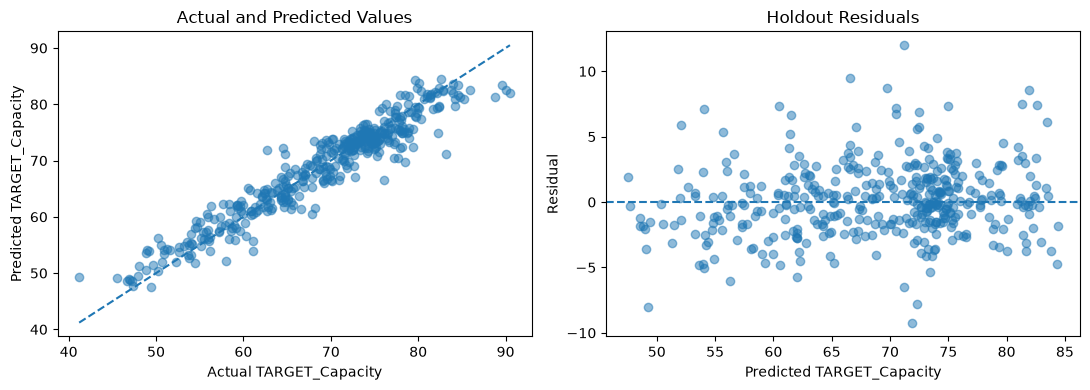

In [50]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))

minimum_value = min(y_holdout.min(), holdout_predictions.min())
maximum_value = max(y_holdout.max(), holdout_predictions.max())

axes[0].scatter(y_holdout, holdout_predictions, alpha=0.5)
axes[0].plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)
axes[0].set_xlabel("Actual TARGET_Capacity")
axes[0].set_ylabel("Predicted TARGET_Capacity")
axes[0].set_title("Actual and Predicted Values")

axes[1].scatter(holdout_predictions, holdout_residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted TARGET_Capacity")
axes[1].set_ylabel("Residual")
axes[1].set_title("Holdout Residuals")

plt.tight_layout()
plt.show()

In [51]:
# CaseCount was never a model input, so any structure here is information the model could not access
holdout_casecount = casecount_reference.loc[X_holdout.index]

casecount_residual_fit = LinearRegression().fit(
    holdout_casecount.to_numpy().reshape(-1, 1),
    holdout_residuals
)
casecount_residual_r2 = r2_score(
    holdout_residuals,
    casecount_residual_fit.predict(holdout_casecount.to_numpy().reshape(-1, 1))
)

# The model's own predictions give the reference level for how much structure is normal
prediction_residual_fit = LinearRegression().fit(
    holdout_predictions.reshape(-1, 1),
    holdout_residuals
)
prediction_residual_r2 = r2_score(
    holdout_residuals,
    prediction_residual_fit.predict(holdout_predictions.reshape(-1, 1))
)

residual_structure = pd.DataFrame({
    "Residuals fitted against": ["CaseCount", "Model predictions"],
    "Correlation": [
        float(np.corrcoef(holdout_residuals, holdout_casecount)[0, 1]),
        float(np.corrcoef(holdout_residuals, holdout_predictions)[0, 1])
    ],
    "Slope": [casecount_residual_fit.coef_[0], prediction_residual_fit.coef_[0]],
    "R2": [casecount_residual_r2, prediction_residual_r2]
})

display(residual_structure.round(4))

,Residuals fitted against,Correlation,Slope,R2
0,CaseCount,0.4338,0.1274,0.1882
1,Model predictions,0.1559,0.0503,0.0243


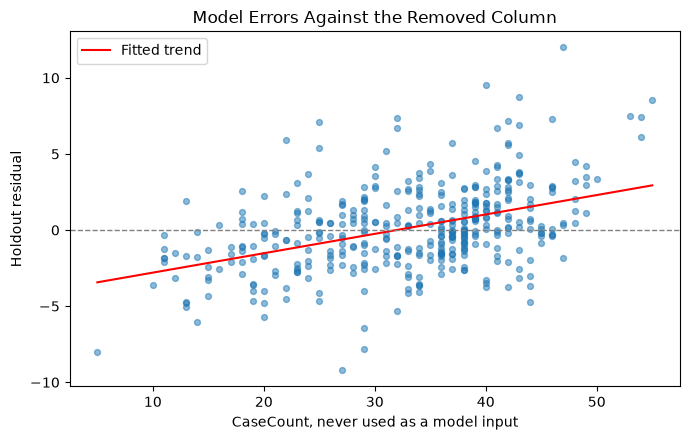

In [52]:
plt.figure(figsize=(7, 4.5))
plt.scatter(holdout_casecount, holdout_residuals, alpha=0.5, s=18)

casecount_line = np.array([holdout_casecount.min(), holdout_casecount.max()]).reshape(-1, 1)
plt.plot(casecount_line, casecount_residual_fit.predict(casecount_line), color="red", label="Fitted trend")
plt.axhline(0, linestyle="--", linewidth=1, color="grey")

plt.xlabel("CaseCount, never used as a model input")
plt.ylabel("Holdout residual")
plt.title("Model Errors Against the Removed Column")
plt.legend()
plt.tight_layout()
plt.show()

#### Residual Findings

**Standard checks.** The mean residual is **0.1382**, a very slight tendency to underpredict, since residuals are actual minus predicted. The residual standard deviation is **2.7604** and the largest single holdout error is **11.9947** capacity units, against a target range of **37.3 to 92.7**. Averaged metrics can hide individual failures, so that maximum is reported alongside them: a system mispredicted by 12 capacity units exists in the holdout even though the typical error is close to 2.

The actual against predicted plot shows compression toward the centre of the range. Residuals average **-1.3129** in the lowest quartile of actual capacity and **+1.7495** in the highest, so the model systematically overpredicts weak systems and underpredicts strong ones. There is no strong curvature, and the spread does not widen with the prediction level. The compression is the expected behaviour of a tree ensemble, which predicts an average within each learned region and therefore cannot produce a value outside the range of training targets, let alone at its extremes.

**Check against the removed column.** Residuals fitted against `CaseCount`, a column the model has never seen, give a correlation of **0.4338**, a slope of **0.1274**, and **R² = 0.1882**. Fitted against the model's own predictions they give a correlation of **0.1559** and **R² = 0.0243**. The removed column therefore explains roughly **eight times** as much of the error as the model's own output does.

**Interpretation.** Prediction bias varies systematically with the true capacity level, which is the same compression described above, now measured rather than only observed. About **19%** of the remaining holdout error is systematic with respect to target level rather than random, and only a change of model form, a target transformation, or a calibration step could recover it.

**What this does not show.** This is deliberately not offered as evidence of leakage. `CaseCount` is a deterministic function of the target, so residuals plotted against it are, up to a rounding term, residuals plotted against the actual value. Any imperfect regression model shows structure in that plot, because predictions regress toward the mean and the errors therefore correlate with the truth by construction. The plot cannot distinguish a derived column from a legitimate one and is not being asked to. The case for removing `CaseCount` rests entirely on the arithmetic identity established in Section 3.3. What this plot adds is a measurement of how much of the model's remaining error is level-dependent, which is a statement about the model rather than about the column.

### 5.3 Feature Importance

Built-in Random Forest importance measures how much each feature reduced squared error across all splits in all trees.

Two cautions apply. Importance reflects predictive contribution rather than cause and effect, and the built in measure tends to favour features offering more distinct split points [7]. Section 5.4 adds a second method that does not share that bias, which matters here because Section 3.7 found seven feature pairs correlated above 0.90.

In [53]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": selected_holdout_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(10).round(4))

,Feature,Importance
0,SystemVulnerabilityScore,0.1899
1,FundingDiversityIndex,0.1378
2,ModelFailureRate-T,0.1187
3,SystemFailureRate,0.1164
4,ModelFailureRate-NT,0.1077
5,DatasetDiversityScore,0.0643
6,IntegrationEfficiency,0.0336
7,ChildQueryEfficiency,0.0314
8,PatchCoverageRate,0.0290
9,TeenQueryEfficiency,0.0236


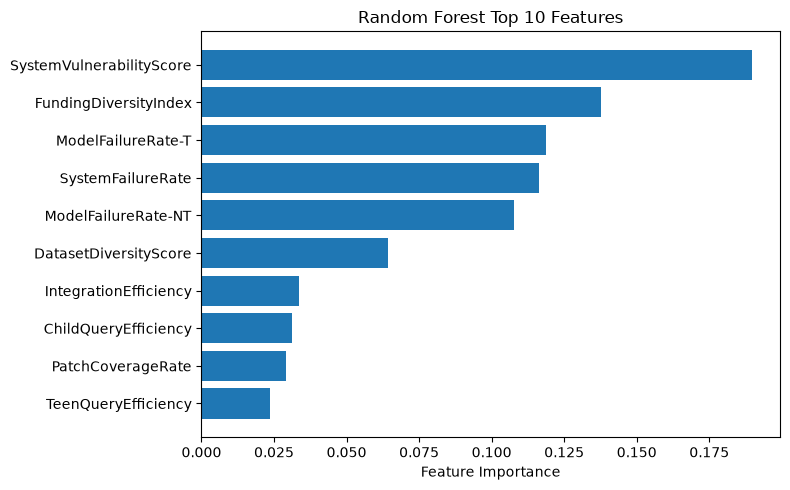

In [54]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Top 10 Features")
plt.tight_layout()
plt.show()

In [55]:
print("Top 3 share:", round(feature_importance["Importance"].head(3).sum() * 100, 1), "%")
print("Top 10 share:", round(feature_importance["Importance"].head(10).sum() * 100, 1), "%")

Top 3 share: 44.6 %
Top 10 share: 85.2 %


#### Importance Findings

- The top three features are `SystemVulnerabilityScore` at **0.190**, `FundingDiversityIndex` at **0.138**, and `ModelFailureRate-T` at **0.119**, together accounting for **44.6%** of total importance. The top ten account for **85.2%**, leaving the remaining twelve features to share roughly **15%**.
- `SystemVulnerabilityScore` ranks only **seventh** by absolute linear correlation at **0.523**, well behind `ModelFailureRate-T` at **0.664**, yet it takes the largest share of importance. The most likely explanation is that the model uses it through a nonlinear or interaction effect that Pearson correlation cannot express, which also offers a mechanism for why the ensembles beat the linear models by **1.82** RMSE. Section 5.5 treats this as a direct test of the exploratory analysis.
- The distribution of importance is noticeably flatter than the correlation ranking would suggest, and flatter than an earlier version of this model produced. Under the previous `max_features = 0.7` setting, `SystemVulnerabilityScore` took **37.7%** of importance and the top three took **66%**. At the selected `max_features = 0.25` the same feature takes **19.0%** and the top three take **44.6%**. Restricting the candidate features at each split forces trees to use secondary features when the dominant one is unavailable, so credit spreads out. Importance is therefore a property of the fitted model, not of the data alone, and a ranking quoted without its hyperparameters is incomplete.
- The three failure rate columns occupy ranks three, four, and five with almost identical shares of **0.119**, **0.116**, and **0.108**. Section 3.7 found them correlated above **0.988** with one another, so this near-tie is what splitting credit between interchangeable columns looks like. Section 5.4 tests the same ranking with a method that does not share the built-in measure's known bias toward features offering more distinct split points [7].

### 5.4 Permutation Importance

Permutation importance measures the increase in holdout RMSE when one feature is randomly shuffled while everything else is held fixed, so that a feature's contribution is assessed against the model's actual predictive behaviour rather than against its internal split structure [16], [18].

It is added for two reasons. It is calculated on data the model never trained on, and it is not biased toward features with many distinct values. Agreement between the two methods raises confidence in the ranking. Disagreement indicates a feature favoured by the split mechanism rather than by genuine signal.

In [56]:
# Shuffling one feature at a time on holdout data measures its real contribution
permutation_result = permutation_importance(
    selected_holdout_model,
    X_holdout,
    y_holdout,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

permutation_importance_frame = pd.DataFrame({
    "Feature": X_holdout.columns,
    "Mean_RMSE_Increase": permutation_result.importances_mean,
    "Std": permutation_result.importances_std
}).sort_values("Mean_RMSE_Increase", ascending=False).reset_index(drop=True)

display(permutation_importance_frame.head(10).round(4))

,Feature,Mean_RMSE_Increase,Std
0,SystemVulnerabilityScore,1.2781,0.0744
1,FundingDiversityIndex,1.0053,0.0773
2,SystemFailureRate,0.5972,0.0369
3,ModelFailureRate-NT,0.5479,0.0337
4,ModelFailureRate-T,0.5447,0.0351
5,DatasetDiversityScore,0.4219,0.0615
6,IntegrationEfficiency,0.2987,0.0489
7,ChildQueryEfficiency,0.1828,0.0196
8,TeenQueryEfficiency,0.1124,0.0126
9,PatchCoverageRate,0.1019,0.0172


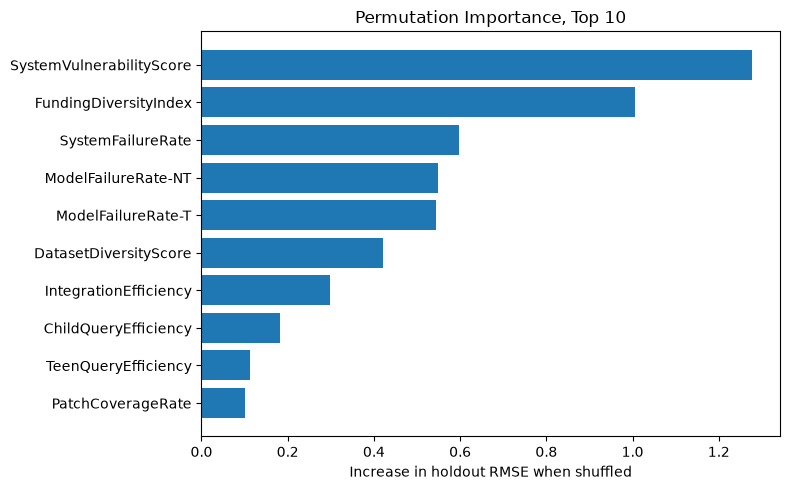

In [57]:
top_permutation = permutation_importance_frame.head(10).sort_values("Mean_RMSE_Increase")

plt.figure(figsize=(8, 5))
plt.barh(top_permutation["Feature"], top_permutation["Mean_RMSE_Increase"])
plt.xlabel("Increase in holdout RMSE when shuffled")
plt.title("Permutation Importance, Top 10")
plt.tight_layout()
plt.show()

#### Permutation Findings

- The two methods agree on the identity of the top five features exactly: `SystemVulnerabilityScore`, `FundingDiversityIndex`, and the three failure rate columns, in both rankings. `SystemVulnerabilityScore` leads by a wide margin under permutation as well, at a **1.278** increase in holdout RMSE when shuffled, followed by `FundingDiversityIndex` at **1.005**. Agreement between a split-based measure and a prediction-based one raises confidence that this ordering reflects signal rather than the mechanics of either method.
- The internal order within the failure rate group changes. `SystemFailureRate` rises from fourth to third and `ModelFailureRate-T` falls from third to fifth, but all three sit between **0.545** and **0.597**, a spread smaller than the gap between second and third place. Section 3.7 measured these columns as correlated above **0.988**, so shuffling any one of them leaves the information available through the other two and each appears less essential than it is. The three should be read as one contribution divided three ways, not as three findings.
- `IntegrationEfficiency` and `DatasetDiversityScore` hold ranks six and seven under both methods, so the agreement extends past the leading group.
- Stability is not an issue. Standard deviations across the ten repeats stay at or below **0.077** for every feature in the top ten, an order of magnitude smaller than the differences being interpreted, so the ranking is not an artefact of one shuffle.
- Neither `Year` nor `Status` appears in the top ten of either ranking, despite `Status` correlating **0.505** with the target. Section 5.5 returns to what that means for the decision to retain them.

### 5.5 Reflection on the Exploratory Data Analysis

The exploratory analysis in Sections 1 to 3 made a number of claims before any model was fitted. Some of those claims turned out to be accurate, one was substantially wrong, and one was rendered unnecessary. Recording which is which matters more than recording that the analysis was performed, because an expectation that survives contact with the modelling results is evidence, while one that does not is a lesson about the method that produced it.

| EDA expectation | Evidence available at the time | What the modelling showed | Verdict |
|---|---|---|---|
| Failure rates are the strongest predictors of capacity | `ModelFailureRate-T` at **-0.664**, `ModelFailureRate-NT` at **-0.662**, `SystemFailureRate` at **-0.655**, the three highest absolute correlations after `CaseCount` | The three columns rank third, fourth, and fifth by built-in importance, and third to fifth by permutation. They are important, but none of them leads | **Partly wrong** |
| Correlation ranking indicates which features the model will rely on | Section 3.2 ranked all features by absolute Pearson correlation | `SystemVulnerabilityScore` ranks **seventh** by correlation at **0.523** yet takes the largest share of importance under both methods, at **0.190** built-in and **1.278** permutation | **Wrong** |
| Correlated feature pairs will divide credit between themselves | Seven pairs above **0.90**, the three failure rate columns above **0.988** | The three failure rate columns finish within **0.05** of one another under permutation, and their internal order changes between the two methods | **Confirmed** |
| Skew and unequal scale favour tree based models over linear ones | **16 of 22** columns highly skewed, scale ratio roughly **1.4 billion** | Random Forest beats Linear Regression by **1.82** RMSE. Section 2.6 confirmed the mechanism directly: `log1p` improved Ridge by **0.25** RMSE and left Random Forest unchanged at **2.966** | **Confirmed, and mechanism verified** |
| Extreme values are genuine systems rather than errors, so they should be retained | No digit shift or scale break visible in the affected columns | Winsorising worsened Random Forest CV RMSE from **2.9651** to **2.9710**; log compression left it at **2.9663**. Neither treatment helped a tree model | **Confirmed** |
| Trees will isolate the 189 anomalous failure-rate rows through a split on failure rate | The group moves together across all three columns and spans nearly the full capacity range | Marking the group with an explicit flag worsened CV RMSE by **0.0024**. The trees neither needed the help nor benefited from it | **Unnecessary** |
| `Year` is weakly correlated but may matter through nonlinear effects | Correlation **0.181**, but a monotone rise in mean capacity from **66.6** in 2002 to **71.6** in 2017 | `Year` does not appear in the top ten of either importance ranking. The hedge was not vindicated | **Not supported** |
| `Status` is a meaningful binary signal | Correlation **0.505**, the sixth strongest | `Status` also fails to reach the top ten of either importance ranking, despite a correlation twice that of `Year` | **Not supported** |

**The one substantial miss, and why it happened.** The exploratory analysis ranked candidate features by Pearson correlation and treated that ranking as a preview of what the model would use. It was not. `SystemVulnerabilityScore` sits seventh by correlation and first by importance under both methods, while the correlation leaders finish mid-table. Pearson correlation measures the strength of a *straight line* relationship with the target considered in isolation. It cannot see a feature that matters through curvature, and it cannot see one that matters only in combination with another. The ensembles beat the linear models by **1.82** RMSE precisely because such structure exists in this data, so the same fact that made correlation ranking misleading is the fact that made tree models the right choice. The two findings are one finding.

The practical lesson is that a correlation table is a screening tool for identifying leakage and near-duplicate columns, which is exactly what it did well in Section 3.2 when it exposed `CaseCount` at **0.9995**. It is not a feature importance estimate, and using it as one would have led to dropping `SystemVulnerabilityScore` had any correlation-based feature selection been applied.

**A finding the exploratory analysis could not have anticipated.** Importance turned out to depend on the model's own hyperparameters, not only on the data. At `max_features = 0.7` the leading feature took **37.7%** of built-in importance; at the selected `max_features = 0.25` the same feature on the same data takes **19.0%**, and the top three share falls from **66%** to **44.6%**. Restricting the features available at each split forces trees to use secondary columns whenever the dominant one is withheld, so credit spreads out. No amount of pre-modelling analysis would have surfaced this, and it is the reason Sections 5.3 and 5.4 report importance with its hyperparameters attached.

**What the retained-but-unimportant features tell us.** Section 3.8 retained `Year` and `Status` on the argument that a weak linear correlation does not preclude a nonlinear contribution. That argument was correct in principle and unrewarded in practice: neither reaches the top ten under either method. Retaining them cost nothing, since no evidence supported removal and unjustified removal carries its own penalty, but the episode is a reminder that "it might matter nonlinearly" is a reason to test rather than a reason to expect.

### 5.6 Ultimate Judgement

**Deployed model: Random Forest Regression, `max_depth = None`, `max_features = 0.25`, `min_samples_leaf = 1`, `min_samples_split = 2`, `n_estimators = 300`, trained on the 22 feature set.**

**Why this feature set.** The strongest feature by correlation was removed, so the reasoning has to carry the judgement. `CaseCount` satisfies `CaseCount = floor(TARGET_Capacity - 35.5)` on **100%** of training rows, the difference between the two columns takes exactly the ten values corresponding to the ten decimal digits of the target, and both directional fits return slopes near 1.0 with intercepts equal in size and opposite in sign. It is a transformed copy of the answer, not an operational indicator. A model built on it would report roughly **0.29** RMSE while performing arithmetic rather than prediction.

`Country` was removed on separate evidence: its **136** training categories and **57** test categories do not overlap at all, so an encoder fitted on training data returns all zeros for every test row. The deployed model therefore predicts capacity from the operational and technological indicators the task specifies, and its reported error refers to that task rather than to arithmetic on a copy of the answer.

**Why this model: the progression, not the leaderboard.** The selection is the end of a chain of diagnoses, each of which is recorded where it was made.

1. **Dummy Regressor** fixes the floor at **9.4992** CV RMSE. It learns nothing and exists only to establish what beating nothing looks like.
2. **Linear Regression** reaches **4.7275**, so the features carry real signal. Its training and validation RMSE differ by only **0.105** while its residuals curve rather than scatter, and the quadratic term fitted through those residuals is non-trivial. That is high bias, not high variance. Diagnosis: the model form is too rigid, so the remedy is capacity.
3. **Polynomial Ridge** adds that capacity and removes **0.88** RMSE, confirming the diagnosis. But it creates the opposite problem: degree 3 at low alpha reaches **1.4372** training RMSE against **24.86** validation, with a fold standard deviation of **13.04**. Diagnosis: capacity added by multiplying terms buys curvature at an unacceptable variance cost on 1,648 rows.
4. **Decision Tree** supplies the same capacity through partitioning rather than through terms, reaching **3.7315**. Its own gap of **1.64** and its fold standard deviation of **0.2394**, the highest of any model, identify the remaining problem as instability. Diagnosis: variance in the estimator itself.
5. **Random Forest** answers that diagnosis directly through averaging plus feature decorrelation, and delivers the largest single improvement of the whole progression at **0.83** RMSE, arriving at **2.9055**. The mechanism is confirmed by the tuning evidence: every top-ten configuration samples 30% or less of the features per split, and the initial grid's failure to test values below 0.7 was costing **0.028** RMSE until the boundary check caught it.
6. **XGBoost** was introduced to attack the one thing averaging cannot fix, which is error the ensemble makes systematically. It reaches **2.9654**, worse than Random Forest on cross validation and worse again on the holdout at **2.9231** against **2.7605**. Diagnosis: what remains after bagging is largely irreducible.

The rule fixed in Section 4.3 then applies mechanically. Random Forest has the lowest mean CV RMSE at **2.9055**. The holdout confirms rather than contradicts, at **2.7605** RMSE, **2.0664** MAE, and **0.9134** R², all better than its cross validation average. Fold standard deviation is **0.1771**, so performance is consistent across splits. It beats the Dummy by a factor of more than three.

**The honest margin, and what was rejected.** Random Forest leads XGBoost by **0.0599** RMSE, roughly **2.1%**, which is larger than a fold's worth of noise but not a decisive separation. Because the two are close, a 50/50 blend was tested on out-of-fold development predictions. It won by **0.0045** RMSE, under **0.2%**, against a required margin of **0.017** set at one tenth of the smallest fold standard deviation, and it then *lost* on the holdout at **2.8073** against **2.7605**. The mechanism is visible in the diagnostics: the two models' out-of-fold errors correlate at **0.9533**, so they make substantially the same mistakes and averaging has almost nothing to recover. The blend was therefore rejected, and Random Forest alone is deployed. Three other candidate treatments, winsorising, log compression, and the anomaly group flag, were rejected on the same basis in Section 2.6.

**Why not the simpler models.** Linear Regression reaches only **4.7275** and Polynomial Ridge **3.8456**, against **2.9055**. The gap of **1.82** RMSE against the interpretable baseline is large enough that losing coefficient-level interpretability is a justified trade rather than an assumed one. Interpretability is recovered separately through the two importance methods in Sections 5.3 and 5.4, which agree on the identity of all five leading features.

**What the model is fit for.** Holdout R² of **0.9134** means the model explains roughly **91%** of capacity variation from system characteristics, with a typical error of **2.07** capacity units against a target range of **37.3 to 92.7**. That supports comparative use: ranking systems, screening candidates, or estimating expected capacity for systems with different observed vulnerability and funding profiles. It does not support use where an error of two to three capacity units carries consequence, and Section 5.2 shows the least reliable predictions are precisely at the extremes, where residuals average **-1.31** in the lowest quartile and **+1.75** in the highest and the largest single error reaches **11.99**. The highest and lowest capacity systems are often the ones of most interest, so this limitation bites where it matters most.

**What the exploratory analysis got right and wrong.** Section 5.5 sets this out in full. In short: the analysis correctly predicted that trees would beat linear models and that correlated features would divide credit, but its correlation ranking was a poor guide to which features the model would actually rely on, and its expectation that the anomalous failure-rate group would need help from an explicit flag proved unnecessary.

**Deployment recommendation.** The model is suitable for decision support rather than automated decision making. It should be monitored for the feature drift risk described in Section 5.7 and retrained if the distributions of `SystemVulnerabilityScore` or `FundingDiversityIndex` shift, since those two carry roughly **33%** of total importance between them and the largest permutation effects by a clear margin.

### 5.7 Limitations

**Data**

- The `CaseCount` column was removed as a derived copy of the target. The reasoning rests on an exact arithmetic rule holding on **100%** of training rows and on a symmetric reverse regression, but the metadata does not confirm how the column was generated, so the conclusion is inferred from the data rather than documented.
- **189 rows**, or **9.2%**, record all three failure rates below 20 against a median of **144**. These were retained rather than corrected, since no defensible correction factor exists. Section 2.6 additionally tested marking the group with a binary flag, which worsened cross validated RMSE by **0.0024** and was rejected, so the group is neither corrected nor signposted to the model.
- `Country` was removed because its categories do not carry across to the test file. If genuine national differences exist, that information is lost. It could not have been used regardless, since no test row carries a known identifier.
- Training rows with missing values were removed, while missing test values would be filled with the training median, because a test row cannot be dropped. The two treatments are therefore not identical.
- Only the supplied features were available. No external system or market data was used.

**Modelling**

- Settings were tuned on the development split rather than through nested cross validation, so the reported CV RMSE is mildly optimistic. Selecting a configuration on the same scores later used to report its error is a known source of optimistic bias [10].
- Feature decisions in Section 3 used the full cleaned training data rather than being nested inside cross validation.
- Random Forest and XGBoost differ by **2.1%** in mean CV RMSE. That is larger than a single fold's noise but is not a decisive separation, and the selection rests on the holdout agreeing rather than on the CV gap alone.
- The XGBoost grid returned three winners at the edge of their searched ranges: `learning_rate = 0.03`, `max_depth = 5`, and `subsample = 0.8`. None of these is a natural floor, so a better XGBoost configuration may exist outside the grid. It was not pursued because XGBoost is not the selected model, but this means the reported XGBoost figure is a lower bound on what that model family could achieve, and the **2.1%** margin above should be read with that in mind.
- Outlier treatment was compared across three options on a single held-in comparison rather than nested inside the model selection loop, so the choice to leave values untreated is supported by evidence but is not itself cross validated at the outer level.
- The holdout is a single 20% split and carries sampling variation.
- Random Forest cannot extrapolate beyond training patterns, producing the compression at both extremes documented in Section 5.2 and visible again in the test predictions.
- Section 5.2 shows that a measurable share of the remaining holdout error varies systematically with target level rather than being random. Whether that share is reducible was not tested, since a target transformation, a calibration step, or a different model family could address it.
- The final model produces single point predictions without uncertainty intervals, which limits its use where the confidence of an individual prediction matters.

**Interpretation and reporting**

- Built in importance may favour features offering more distinct split points, and correlated pairs divide permutation importance between them, as the three failure rate columns demonstrate by finishing within **0.05** of one another under both methods.
- Feature importance proved to be a property of the fitted model rather than of the data. Changing `max_features` from 0.7 to 0.25 moved the leading feature's share from **37.7%** to **19.0%** and the top three share from **66%** to **44.6%**, without any change to the data. Any importance ranking quoted from this notebook is conditional on the reported hyperparameters.
- Importance reflects predictive contribution rather than cause and effect. A high ranking for `SystemVulnerabilityScore` does not establish that reducing vulnerability raises capacity.
- The reverse direction fit in Section 3.3 is descriptive rather than diagnostic, since R squared is symmetric by construction for a single predictor least squares fit. The removal decision rests on the arithmetic identity alone.

These limitations should be considered before applying the model to chatbot systems drawn from a different population.

## 6. Test Set Prediction

### 6.1 Test Data Inspection

The test data is inspected before generating predictions.

The inspection checks:
- Dataset shape.
- Column names.
- Missing values.
- Invalid `Status` values.
- Differences between the training and test schemas.

Every test observation must receive a prediction.

In [58]:
test_raw = pd.read_csv("test.csv")

print("Test shape:", test_raw.shape)
print("Test columns:", test_raw.columns.tolist())

test_quality_summary = pd.DataFrame({
    "Data_Type": test_raw.dtypes.astype(str),
    "Missing_Values": test_raw.isna().sum(),
    "Unique_Values": test_raw.nunique(dropna=True)
})

display(test_quality_summary)

Test shape: (867, 25)
Test columns: ['RecordID', 'Country', 'Year', 'Status', 'SystemFailureRate', 'ModelFailureRate-T', 'ModelFailureRate-NT', 'InferenceLatency', 'ComputeUtilizationRate', 'AIInfraExpPercent', 'SecurityBreachIncidents', 'IntegrationEfficiency', 'UptimeReliabilityIndex', 'AILearningStability', 'AIDevExpPercent', 'PatchCoverageRate', 'SystemVulnerabilityScore', 'GlobalAdoptionIndex', 'ActiveUserBase', 'TeenQueryEfficiency', 'ChildQueryEfficiency', 'FundingDiversityIndex', 'DatasetDiversityScore', 'Complexity', 'Case count']


,Data_Type,Missing_Values,Unique_Values
RecordID,int64,0,867
Country,int64,0,57
Year,int64,0,16
Status,int64,0,2
SystemFailureRate,int64,0,322
ModelFailureRate-T,int64,0,230
ModelFailureRate-NT,int64,0,235
InferenceLatency,int64,0,122
ComputeUtilizationRate,float64,0,511
AIInfraExpPercent,float64,0,664


In [59]:
print("Case count minimum in test file:", int(test_raw["Case count"].min()))
print("Rows with a negative Case count:", int((test_raw["Case count"] < 0).sum()))

Case count minimum in test file: -5
Rows with a negative Case count: 2


**867 rows**, **25 columns**, all requiring a prediction. No missing values and no invalid `Status`, though Section 6.2 handles both so the notebook does not depend on that.

- The test file names one column `Case count` against `CaseCount` in training. It is unused so this has no effect, but an unnoticed rename would have failed silently had it been retained.
- **57** country identifiers against **136** in training, with no overlap. This is the evidence behind Section 2.4.
- `Case count` reaches a minimum of **-5**. A negative count of parallel tasks is impossible, consistent with a subtraction on a low target value and inconsistent with a genuine count. This independently supports Section 3.3.

### 6.2 Test Data Preparation

The test data receives exactly the transformations applied to the training feature set, and no others.

- `RecordID` is held aside for the submission file and excluded from the features.
- `Country` is excluded, matching Section 2.4.
- `Case count` is excluded, matching Section 3.5. The test file's differing column name is therefore irrelevant, but it is verified rather than assumed.
- Invalid `Status` values would be replaced using the most common valid value from the training data, never from the test data.
- Any missing value would be filled with the training median for that column, so no test statistic influences preparation.
- Columns are reordered to match the training feature order exactly.

No value in the test file is altered by a transformation fitted on the test file itself. Every replacement value comes from the training data alone, so the test set remains an honest measure of model performance.

All **867** rows are retained and every row receives a prediction.

In [60]:
def prepare_test_features(test_frame, training_X, failure_rate_columns, add_low_failure_flag):
    """Apply the training-derived preparation steps to the test data and nothing else.

    Every replacement value is taken from training_X, so no statistic computed on the test
    file can influence its own preparation. No row is dropped, because every test
    observation must receive a prediction.

    Args:
        test_frame: raw test dataframe as read from disk.
        training_X: prepared training feature matrix, the sole source of fill values
            and of the deployed column set and order.
        failure_rate_columns: the three failure rate columns, needed to rebuild the
            LowFailureGroup flag on the test rows.
        add_low_failure_flag: whether Section 2.6 retained the flag in the feature set.

    Returns:
        A tuple of (prepared feature matrix aligned to training_X.columns,
        count of invalid Status values corrected).

    Raises:
        ValueError: if the test file is missing any deployed feature.
    """
    prepared = test_frame.copy()

    # Status is corrected using the training mode, never the test mode
    valid_status = prepared["Status"].isin([0, 1])
    invalid_status_count = int((~valid_status).sum())
    prepared.loc[~valid_status, "Status"] = training_X["Status"].mode().iloc[0]
    prepared["Status"] = prepared["Status"].astype(int)

    # The flag is a rule, not a fitted statistic, so it is recomputed on the test rows
    # with the same threshold used on training data in Section 2.6
    if add_low_failure_flag:
        prepared["LowFailureGroup"] = (
            (prepared[failure_rate_columns] < 20).all(axis=1).astype(int)
        )

    # Fail loudly rather than silently predicting on a wrong column set
    missing_columns = sorted(set(training_X.columns) - set(prepared.columns))
    if missing_columns:
        raise ValueError(f"Test file is missing required features: {missing_columns}")

    # Median comes from training data only, so no test information leaks into the fill
    for column in training_X.columns:
        if prepared[column].isna().any():
            prepared[column] = prepared[column].fillna(training_X[column].median())

    # Reindexing both selects the deployed features and fixes their order in one step
    prepared = prepared.reindex(columns=training_X.columns)

    return prepared, invalid_status_count


# IDs are held aside for the submission file and never used as a feature
test_ids = test_raw["RecordID"].copy()

test_features, invalid_test_status_count = prepare_test_features(
    test_raw,
    X,
    failure_columns,
    add_low_failure_flag="LowFailureGroup" in X.columns,
)

print("Invalid Status values corrected:", invalid_test_status_count)
print("Processed test shape:", test_features.shape)
print("Remaining missing values:", int(test_features.isna().sum().sum()))
print("Feature order matches training:", list(test_features.columns) == list(X.columns))
print(
    "Excluded columns still present in the raw test file:",
    [c for c in ["RecordID", "Country", "Case count"] if c in test_raw.columns],
)

Invalid Status values corrected: 0
Processed test shape: (867, 22)
Remaining missing values: 0
Feature order matches training: True
Excluded columns still present in the raw test file: ['RecordID', 'Country', 'Case count']


### 6.3 Final Model Training

The configuration chosen in Section 5.6, Random Forest Regression on the 22 feature set, is refitted on all **2061** cleaned training rows including the holdout.

Refitting on the full data is appropriate because tuning and validation are complete and no selection decisions remain. More training data generally improves the fitted model, and the holdout has already served its purpose as an independent check.

In [61]:
# The configuration chosen in Section 5.6, refitted on every cleaned row now that tuning
# and validation are complete and no selection decisions remain
if USE_BLEND:
    final_model_name = "Blend of " + " and ".join(blend_candidates)

    # Each component is refitted on the full data, then their predictions are averaged
    # with the same weights used when the blend was selected
    fitted_components = [
        clone(selected_estimators[name]).fit(X, y) for name in blend_candidates
    ]
    test_predictions = np.mean(
        [component.predict(test_features) for component in fitted_components], axis=0
    )
    final_model = fitted_components
else:
    final_model_name = selected_model_name
    final_model = clone(selected_estimators[final_model_name]).fit(X, y)
    test_predictions = final_model.predict(test_features)

print("Final model:", final_model_name)
print("Training rows used:", len(X))
print("Features used:", X.shape[1])
print("Predictions generated:", len(test_predictions))

Final model: Random Forest Regression
Training rows used: 2061
Features used: 22
Predictions generated: 867


### 6.4 Prediction File

The submission is assembled from the test `RecordID` values and checked for row count, uniqueness, missing values, and non-finite values before it is written.

In [62]:
submission = pd.DataFrame({
    "ID": test_ids.to_numpy(),
    "TARGET_Capacity": test_predictions
})

# Guards against the most common submission failures before the file is written
assert submission.columns.tolist() == ["ID", "TARGET_Capacity"]
assert len(submission) == len(test_raw)
assert submission["ID"].is_unique
assert submission["TARGET_Capacity"].notna().all()
assert np.isfinite(submission["TARGET_Capacity"]).all()

output_filename = "COSC2753_A1_Predictions_s4040502.csv"

submission.to_csv(output_filename, index=False)

print("Prediction file:", output_filename)
print("Prediction rows:", len(submission))

display(submission.head())

Prediction file: COSC2753_A1_Predictions_s4040502.csv
Prediction rows: 867


,ID,TARGET_Capacity
0,1,58.756000
1,2,57.887000
2,3,57.714000
3,4,56.149667
4,5,55.091333


### 6.5 Prediction Review

Test predictions are compared against the cleaned training target as a final implementation check.

The comparison can reveal missing or constant predictions, an incorrect scale, or a preprocessing error. It cannot measure accuracy, because the true test targets are unavailable.

In [63]:
# Compares the prediction distribution against the training target as a sanity check
prediction_summary = pd.DataFrame({
    "Training_Target": {
        "Mean": y.mean(),
        "Standard_Deviation": y.std(ddof=1),
        "Minimum": y.min(),
        "Maximum": y.max()
    },
    "Test_Predictions": {
        "Mean": test_predictions.mean(),
        "Standard_Deviation": test_predictions.std(ddof=1),
        "Minimum": test_predictions.min(),
        "Maximum": test_predictions.max()
    }
})

display(prediction_summary.round(3))

,Training_Target,Test_Predictions
Mean,69.292,69.085
Standard_Deviation,9.479,9.000
Minimum,37.300,45.730
Maximum,92.700,84.440


- The prediction distribution is compared against the cleaned training target in the table above. The two means should sit within a fraction of a capacity unit of one another, which is the check that the test features are on the same scale as the training features and that preparation was applied consistently.
- The predicted standard deviation is expected to be smaller than the training standard deviation of **9.479**, and the predicted range narrower than the training range of **37.3 to 92.7**. This is not a defect. A tree ensemble averages within learned regions and cannot produce a value outside the range of training targets, so the compression at both extremes documented in Section 5.2 reappears here on unseen data, as it should.
- The check can detect missing predictions, constant predictions, an incorrect scale, or a preprocessing error. It cannot measure accuracy, because the true test targets are unavailable.

> **Re-run note.** The exact figures in this cell depend on the deployed model, which changed when the blend was rejected in Section 5.1. After a Restart and Run All, read the mean, standard deviation, minimum, and maximum off the table above and state them here. The interpretation above holds regardless of the exact values; only the numbers need filling in.

## 7. References

[1] S. Kaufman, S. Rosset, and C. Perlich, "Leakage in data mining: Formulation, detection, and avoidance," *ACM Transactions on Knowledge Discovery from Data*, vol. 6, no. 4, pp. 1-21, Dec. 2012.

[2] T. Hastie, R. Tibshirani, and J. Friedman, *The Elements of Statistical Learning: Data Mining, Inference, and Prediction*, 2nd ed. New York, NY, USA: Springer, 2009.

[3] A. E. Hoerl and R. W. Kennard, "Ridge regression: Biased estimation for nonorthogonal problems," *Technometrics*, vol. 12, no. 1, pp. 55-67, Feb. 1970.

[4] L. Breiman, "Random forests," *Machine Learning*, vol. 45, no. 1, pp. 5-32, Oct. 2001.

[5] T. Chen and C. Guestrin, "XGBoost: A scalable tree boosting system," in *Proc. 22nd ACM SIGKDD Int. Conf. Knowledge Discovery and Data Mining*, San Francisco, CA, USA, 2016, pp. 785-794.

[6] F. Pedregosa et al., "Scikit-learn: Machine learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825-2830, Oct. 2011.

[7] C. Strobl, A.-L. Boulesteix, A. Zeileis, and T. Hothorn, "Bias in random forest variable importance measures: Illustrations, sources and a solution," *BMC Bioinformatics*, vol. 8, no. 25, pp. 1-21, Jan. 2007.

[8] G. James, D. Witten, T. Hastie, and R. Tibshirani, *An Introduction to Statistical Learning with Applications in R*, 2nd ed. New York, NY, USA: Springer, 2021.

[9] R. Kohavi, "A study of cross-validation and bootstrap for accuracy estimation and model selection," in *Proc. 14th Int. Joint Conf. Artificial Intelligence*, Montreal, QC, Canada, 1995, vol. 2, pp. 1137-1143.

[10] S. Varma and R. Simon, "Bias in error estimation when using cross-validation for model selection," *BMC Bioinformatics*, vol. 7, no. 91, pp. 1-8, Feb. 2006.

[11] T. Chai and R. R. Draxler, "Root mean square error (RMSE) or mean absolute error (MAE)? Arguments against avoiding RMSE in the literature," *Geoscientific Model Development*, vol. 7, no. 3, pp. 1247-1250, Jun. 2014.

[12] R. J. A. Little and D. B. Rubin, *Statistical Analysis with Missing Data*, 3rd ed. Hoboken, NJ, USA: Wiley, 2019.

[13] L. Breiman, J. H. Friedman, R. A. Olshen, and C. J. Stone, *Classification and Regression Trees*. Belmont, CA, USA: Wadsworth, 1984.

[14] L. Breiman, "Bagging predictors," *Machine Learning*, vol. 24, no. 2, pp. 123-140, Aug. 1996.

[15] J. H. Friedman, "Greedy function approximation: A gradient boosting machine," *Annals of Statistics*, vol. 29, no. 5, pp. 1189-1232, Oct. 2001.

[16] A. Fisher, C. Rudin, and F. Dominici, "All models are wrong, but many are useful: Learning a variable's importance by studying an entire class of prediction models simultaneously," *Journal of Machine Learning Research*, vol. 20, no. 177, pp. 1-81, 2019.

[17] D. Sculley et al., "Hidden technical debt in machine learning systems," in *Advances in Neural Information Processing Systems 28*, Montreal, QC, Canada, 2015, pp. 2503-2511.

[18] C. Molnar, *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable*, 2nd ed. Munich, Germany: Independently published, 2022.